# Statistical & Machine Learning Analysis of Airbnb Listings in NYC (2024)

## Problem Statement

##### The rapid growth of short-term rentals has transformed New York City's hoursing and tourism markets, raising important questions about pricing, demand, host strategies, and regulatory compliance. This project aims to analyze over 20,000 Airbnb listings in NYC to uncover how property characterstics, host behaviors, and neighborhood factors influence pricing and guest demand. By combining descriptive, inferential, and machine learning methods, the study seeks to 

##### 1. Identify key drivers of price differences across boroughs and room types
##### 2. Evaluate the impact of host strategies on market outcomes, and
##### 3. Discover latent market segments among listings and neighborhoods.

##### The ultimate goal is to generate insights that are statistically rigorous, interpretable, and practically relevant for hosts, guests, policymakers, and platform stakeholders. 

## Research Questions

### 1. Market Pricing Dynamics
- How do nightly prices differ across boroughs and room types?
- What property and location characterstics are the strongest predictors of price?

### 2. Host Strategy & Market Behavior 
- Do multi-listing hosts set different prices compared to single-listing hosts?
- How does host strategy influence guest engagement, as measured by reviews?

### 3. Guest Demand & Activity
- Can listings be classified into high-demand vs. low-demand segments based on review activity?

### 4. Market Segmentation & Clustering
- What clusters of listings exist when considering price, host behavior, reviews, and ratings?


### Loading Dataset


In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.oneway as oneway
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.stats import mannwhitneyu
from sklearn.inspection import permutation_importance
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

In [7]:
# loading dataset
df = pd.read_csv("airbnb_dataset.csv", encoding_errors='ignore')
df.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,1.312228e+06,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.683710,-73.964610,Private room,55.0,...,20/12/15,0.03,1.0,0.0,0.0,No License,5,1,1,Not specified
1,4.527754e+07,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,01/05/23,0.24,139.0,364.0,2.0,No License,4.67,2,1,1
2,9.710000e+17,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,18/12/23,1.67,1.0,343.0,6.0,Exempt,4.17,1,2,1
3,3.857863e+06,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,17/09/23,1.38,2.0,363.0,12.0,No License,4.64,1,1,1
4,4.089661e+07,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,...,03/12/23,0.24,133.0,335.0,3.0,No License,4.91,Studio,1,1


In [8]:
# shape of dataframe
print("shape (rows, cols):", df.shape)

shape (rows, cols): (20770, 22)


In [9]:
# Data types of each column
df.dtypes

id                                float64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                    float64
number_of_reviews                 float64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                  float64
number_of_reviews_ltm             float64
license                            object
rating                             object
bedrooms                           object
beds                                int64
baths                              object
dtype: object

### Data Cleaning

In [11]:
#converting id to integer (avoid scientific notation)
df['id'] = df['id'].round().astype('Int64')

#converting last_review to datetime (day first = True for DD/MM/YY format)
df['last_review'] = pd.to_datetime(df['last_review'], dayfirst=True, errors = 'coerce')

#converting rating to numeric (invalid values = NaN)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

#converting bedrooms: "Studio" = 0, others numeric
def to_bedrooms_num(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if x == 'studio':
        return 0
    try: 
        return float(x)
    except:
        return np.nan

df['bedrooms_num'] = df['bedrooms'].apply(to_bedrooms_num)

#converting baths: invalid or "Not_specified" = NaN
df['baths_num'] = pd.to_numeric(df['baths'], errors='coerce')

#sample rows
df[['id', 'last_review', 'rating', 'bedrooms', 'bedrooms_num', 'baths', 'baths_num']].head(10)

/var/folders/gb/z7h6x7g11vd53ygq0mqb_s2h0000gn/T/ipykernel_22593/1953713949.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['last_review'] = pd.to_datetime(df['last_review'], dayfirst=True, errors = 'coerce')


,id,last_review,rating,bedrooms,bedrooms_num,baths,baths_num
0,1312228,2015-12-20,5.00,1,1.0,Not specified,NaN
1,45277537,2023-05-01,4.67,2,2.0,1,1.0
2,971000000000000000,2023-12-18,4.17,1,1.0,1,1.0
3,3857863,2023-09-17,4.64,1,1.0,1,1.0
4,40896611,2023-12-03,4.91,Studio,0.0,1,1.0
5,49584983,2023-07-29,5.00,1,1.0,1,1.0
6,45277537,2023-05-01,4.67,2,2.0,1,1.0
7,971000000000000000,2023-12-18,4.17,1,1.0,1,1.0
8,3857863,2023-09-17,4.64,1,1.0,1,1.0
9,40896611,2023-12-03,4.91,Studio,0.0,1,1.0


In [12]:
#Count of missing values per column
print("missing values count: \n")
print(df.isnull().sum())

missing values count: 

id                                   0
name                                 0
host_id                              0
host_name                            0
neighbourhood_group                  0
neighbourhood                        7
latitude                             7
longitude                            7
room_type                            7
price                               34
minimum_nights                       7
number_of_reviews                    7
last_review                          7
reviews_per_month                    7
calculated_host_listings_count       7
availability_365                     7
number_of_reviews_ltm                7
license                              0
rating                            3754
bedrooms                             0
beds                                 0
baths                                0
bedrooms_num                         0
baths_num                           13
dtype: int64


In [13]:
print("Missing values percentage:\n")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing values percentage:

id                                 0.00
name                               0.00
host_id                            0.00
host_name                          0.00
neighbourhood_group                0.00
neighbourhood                      0.03
latitude                           0.03
longitude                          0.03
room_type                          0.03
price                              0.16
minimum_nights                     0.03
number_of_reviews                  0.03
last_review                        0.03
reviews_per_month                  0.03
calculated_host_listings_count     0.03
availability_365                   0.03
number_of_reviews_ltm              0.03
license                            0.00
rating                            18.07
bedrooms                           0.00
beds                               0.00
baths                              0.00
bedrooms_num                       0.00
baths_num                          0.06
dtype: float

critical columns like price, location, room_type have very low percentage of missing values ~0.03%. So we simply drop these rows. 

In [15]:
# Droping rows with critical missing values
critical_cols = ['price', 'neighbourhood', 'room_type', 'latitude', 'longitude']
df = df.dropna(subset=critical_cols)

print("shape after dropping critical nulls:", df.shape)

shape after dropping critical nulls: (20736, 24)


In [16]:
#rechecking missingness 
(df.isnull().sum() / len(df) * 100).round(2).sort_values(ascending=False).head(10)

rating                   18.09
baths_num                 0.06
name                      0.00
bedrooms_num              0.00
baths                     0.00
beds                      0.00
bedrooms                  0.00
license                   0.00
number_of_reviews_ltm     0.00
availability_365          0.00
dtype: float64

In [17]:
#statistical summaries
display(df.describe().T)

,count,mean,min,25%,50%,75%,max,std
id,20736.0,303712577179221824.0,2595.0,27089219.25,49943354.5,722000000000000000.0,1050000000000000000.0,390221762102306944.0
host_id,20736.0,174972881.828077,1678.0,20433973.0,108843897.0,314422057.5,550403525.0,172589404.731771
latitude,20736.0,40.726862,40.500314,40.684177,40.72296,40.76314,40.911147,0.060313
longitude,20736.0,-73.939178,-74.24984,-73.9808,-73.94962,-73.91746,-73.71365,0.061435
price,20736.0,187.71494,10.0,80.0,125.0,199.0,100000.0,1023.245124
minimum_nights,20736.0,28.564525,1.0,30.0,30.0,30.0,1250.0,33.551588
number_of_reviews,20736.0,42.586179,1.0,4.0,14.0,49.0,1865.0,73.521954
last_review,20736,2023-02-24 12:31:15,2011-12-10 00:00:00,2023-04-09 00:00:00,2023-09-19 00:00:00,2023-11-25 00:00:00,2024-01-05 00:00:00,NaN
reviews_per_month,20736.0,1.2573,0.01,0.21,0.65,1.8,75.49,1.904798
calculated_host_listings_count,20736.0,18.859279,1.0,1.0,2.0,5.0,713.0,70.944524


In [18]:
#Deep dive on key variables
key_vars = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365', 'calculated_host_listings_count']
display(df[key_vars].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
price,20736.0,187.714940,1023.245124,10.00,33.00,43.00,80.00,125.00,199.0,429.25,999.00,100000.00
minimum_nights,20736.0,28.564525,33.551588,1.00,1.00,1.00,30.00,30.00,30.0,30.00,90.00,1250.00
number_of_reviews,20736.0,42.586179,73.521954,1.00,1.00,1.00,4.00,14.00,49.0,179.00,328.65,1865.00
reviews_per_month,20736.0,1.257300,1.904798,0.01,0.02,0.05,0.21,0.65,1.8,4.04,6.36,75.49
availability_365,20736.0,206.000338,135.093463,0.00,0.00,0.00,87.00,215.00,353.0,365.00,365.00,365.00
calculated_host_listings_count,20736.0,18.859279,70.944524,1.00,1.00,1.00,1.00,2.00,5.0,84.00,267.00,713.00


We can see there are extreme outliers in price, minimum_nights, and reviews_per_month. So we need to visualize them and then cap or remove them before statistical tests or modeling. 

In [20]:
#checking for duplicates
#total duplicate rows (entire row duplicate)
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 12


In [21]:
#duplicate IDs 
print("Duplicate listing IDs:", df['id'].duplicated().sum())



Duplicate listing IDs: 7562


In [22]:
#if duplicates exist, preview them
if df['id'].duplicated().any():
    display(df[df['id'].duplicated(keep=False)].head(10))

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths,bedrooms_num,baths_num
1,45277537,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,139.0,364.0,2.0,No License,4.67,2,1,1,2.0,1.0
2,971000000000000000,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,1.0,343.0,6.0,Exempt,4.17,1,2,1,1.0,1.0
3,3857863,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,2.0,363.0,12.0,No License,4.64,1,1,1,1.0,1.0
4,40896611,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,...,133.0,335.0,3.0,No License,4.91,Studio,1,1,0.0,1.0
5,49584983,Rental unit in New York · ★5.0 · 1 bedroom · 1...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.759950,-73.992960,Entire home/apt,115.0,...,139.0,276.0,2.0,No License,5.00,1,1,1,1.0,1.0
6,45277537,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,139.0,364.0,2.0,No License,4.67,2,1,1,2.0,1.0
7,971000000000000000,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,1.0,343.0,6.0,Exempt,4.17,1,2,1,1.0,1.0
8,3857863,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,2.0,363.0,12.0,No License,4.64,1,1,1,1.0,1.0
9,40896611,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,...,133.0,335.0,3.0,No License,4.91,Studio,1,1,0.0,1.0
10,49584983,Rental unit in New York · ★5.0 · 1 bedroom · 1...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.759950,-73.992960,Entire home/apt,115.0,...,139.0,276.0,2.0,No License,5.00,1,1,1,1.0,1.0


In [23]:
# Checking how many times each ID repeats
dup_counts = df['id'].value_counts()
print("IDs with more than 1 occurrence:", (dup_counts > 1).sum())

IDs with more than 1 occurrence: 482


In [24]:
#Looking at one example duplicate ID
example_id = dup_counts[dup_counts > 1].index[0]
print(f"n/Example duplicate ID: {example_id}")
display(df[df['id'] == example_id])

n/Example duplicate ID: 1020000000000000000


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths,bedrooms_num,baths_num
152,1020000000000000000,Home in New York · ★4.40 · 1 bedroom · 1 bed ·...,544652279,Rop,Manhattan,Harlem,40.811672,-73.942155,Private room,85.0,...,3.0,87.0,10.0,Exempt,4.40,1,1,1,1.0,1.0
369,1020000000000000000,Rental unit in New York · ★5.0 · 1 bedroom · 2...,91436483,Tom,Manhattan,Murray Hill,40.748092,-73.979733,Entire home/apt,231.0,...,1.0,174.0,4.0,Exempt,5.00,1,2,1,1.0,1.0
460,1020000000000000000,Rental unit in New York · ★5.0 · 1 bedroom · 1...,546516635,Raman,Manhattan,Chelsea,40.744766,-73.999864,Entire home/apt,295.0,...,1.0,317.0,6.0,Exempt,5.00,1,1,1,1.0,1.0
511,1020000000000000000,Loft in New York · ★New · 1 bedroom · 2 beds ·...,545416054,Charles,Manhattan,Harlem,40.812870,-73.945370,Entire home/apt,257.0,...,10.0,270.0,2.0,Exempt,NaN,1,2,1,1.0,1.0
512,1020000000000000000,Rental unit in New York · ★5.0 · 2 bedrooms · ...,396845074,Ally,Manhattan,Midtown,40.748350,-73.967670,Entire home/apt,695.0,...,3.0,257.0,3.0,Exempt,5.00,2,1,2,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20031,1020000000000000000,Guesthouse in Queens · ★5.0 · 1 bedroom · 1 be...,5735865,Usquire,Queens,Jamaica Hills,40.709042,-73.803376,Entire home/apt,77.0,...,20.0,262.0,3.0,Exempt,5.00,1,1,1,1.0,1.0
20113,1020000000000000000,Home in Queens · ★4.60 · 2 bedrooms · 2 beds ·...,100573908,Jiale,Queens,College Point,40.780970,-73.842650,Entire home/apt,179.0,...,2.0,171.0,5.0,Exempt,4.60,2,2,1,2.0,1.0
20374,1020000000000000000,Rental unit in NEW YORK · ★New · 3 bedrooms ·...,467872558,Jocelyn,Manhattan,Harlem,40.822830,-73.954940,Entire home/apt,249.0,...,3.0,238.0,1.0,Exempt,NaN,3,3,1,3.0,1.0
20467,1020000000000000000,Rental unit in Brooklyn · ★5.0 · 1 bedroom · 2...,429941031,Jennaya,Brooklyn,Clinton Hill,40.688020,-73.965800,Entire home/apt,107.0,...,7.0,36.0,7.0,Exempt,5.00,1,2,1,1.0,1.0


In [25]:
# droping exact duplicate rows
df = df.drop_duplicates()

print("Shape after dropping exact duplicates:", df.shape)

Shape after dropping exact duplicates: (20724, 24)


Now, as we can see there are 114 different rows with same ID, that means Id is not a reliable primary key. 

we also drop the ID column, and add a synthetic unique_id column as the technical identifier. Use host_id when doing host-level analysis, and location/room_type/price when analyzing listings. 

In [27]:
# Dropping the broken 'id' column
df = df.drop(columns = ['id'])

# adding a new synthetic unique identifier
df['unique_id'] = range(1, len(df)+1)

print("shape after cleaning:", df.shape)
df.head()

shape after cleaning: (20724, 24)


,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths,bedrooms_num,baths_num,unique_id
0,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.683710,-73.964610,Private room,55.0,30.0,...,0.0,0.0,No License,5.00,1,1,Not specified,1.0,NaN,1
1,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,30.0,...,364.0,2.0,No License,4.67,2,1,1,2.0,1.0,2
2,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,2.0,...,343.0,6.0,Exempt,4.17,1,2,1,1.0,1.0,3
3,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,30.0,...,363.0,12.0,No License,4.64,1,1,1,1.0,1.0,4
4,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,30.0,...,335.0,3.0,No License,4.91,Studio,1,1,0.0,1.0,5


- The original 'id' column was expected to be a **unique identifier** for each listing. 

- However, upon inspection we found that:

    - Only 12 rows were exact full-row duplicates (removed).
    - Over 7500 duplicate Ids existed, and many IDs were repeated across hundreds of different rows with different host, price and neighborhoods.
    - This confirmed that 'Id' was not a reliable primary key in this dataset.


- To avoid misleading analysis:
     - We dropped the **Id** column entirely.
     - We created a new synthetic unique identifier column called **'unique_id'** (simply row index + 1).
     - This ensures every row is uniquely identifiable for technical purpose.

- For analysis going forward:
    - unique id -> internal technical identifier
    - host_id -> used for host-level analysis (eg. single vs multiple-listing hosts)
    - property level variables like 'price', 'room_type', 'neighbourhodd', 'availability_365' -> used for market, pricing, and demand analysis. 

Data Cleaning Summary

1. **Data Types** → Fixed `last_review` (datetime), `rating` (numeric), `bedrooms` & `baths` (numeric).  
2. **Missing Values** → Dropped rows with critical nulls; kept NaN for `rating` & `baths_num`.  
3. **Duplicates** → Removed 12 exact duplicates; found `id` not unique across listings.  
4. **ID Handling** → Dropped `id`; created synthetic `unique_id` for uniqueness.  


### Exploratory Data Analysis

#### Univariate Analysis

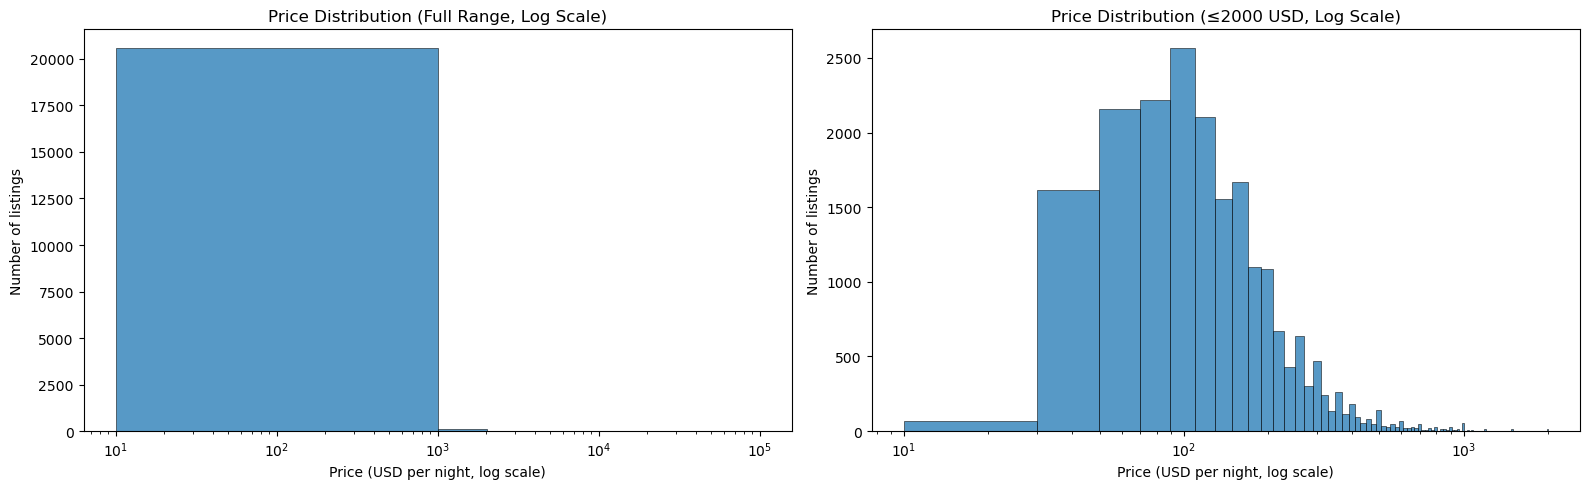

In [31]:
# Price Distribution
fig, axes = plt.subplots(1,2,figsize=(16,5))

#full range histogram
sns.histplot(df['price'], bins=100, kde=False, ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("Price Distribution (Full Range, Log Scale)")
axes[0].set_xlabel("Price (USD per night, log scale)")
axes[0].set_ylabel("Number of listings")

#Capped histogram (focus on main body)
sns.histplot(df[df['price'] <= 2000]['price'], bins=100, kde=False, ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Price Distribution (≤2000 USD, Log Scale)")
axes[1].set_xlabel("Price (USD per night, log scale)")
axes[1].set_ylabel("Number of listings")

plt.tight_layout()
plt.show()

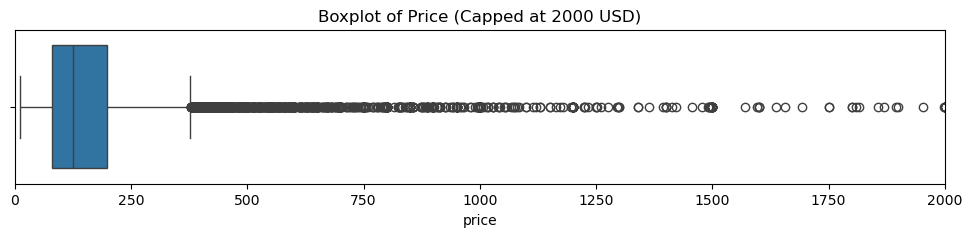

In [32]:
#Boxplot for capped view
plt.figure(figsize=(12,2))
sns.boxplot(x=df['price'])
plt.xlim(0,2000)
plt.title("Boxplot of Price (Capped at 2000 USD)")
plt.show()

The price variable showed extreme outliers (up to $\$100,000$) that distort distributions. So the median = $ \$125$, 95th percentile = $\$429$ and 99th percentile = $\$999$. To remove unrealistic cases while retaining market-relevant data, we restricted the price range to **$\$10-\$1000$**. 

The preserves $\approx99\%$ of listings and ensures analysis reflects realistic pricing patterns. 

In [34]:
#Filtering Price outliers
df = df[(df['price'] >= 10) & (df['price'] <= 1000)]

print("Shape after price filtering:", df.shape)

# new price distribution
print(df['price'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

Shape after price filtering: (20557, 24)
count    20557.000000
mean       161.262101
std        131.961564
min         10.000000
1%          33.000000
5%          43.000000
25%         80.000000
50%        125.000000
75%        199.000000
95%        400.000000
99%        749.000000
max       1000.000000
Name: price, dtype: float64


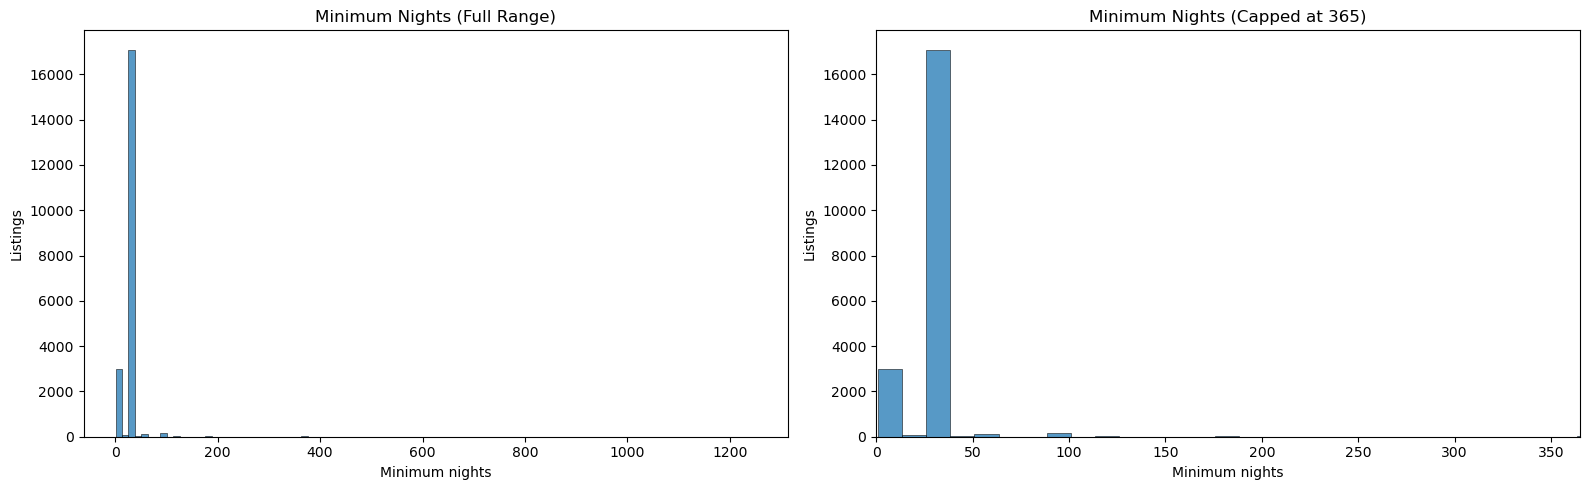

In [35]:
#Distribution for Minimum Nights
fig, axes = plt.subplots(1, 2, figsize=(16,5))

sns.histplot(df['minimum_nights'], bins=100, ax=axes[0])
axes[0].set_title("Minimum Nights (Full Range)")
axes[0].set_xlabel("Minimum nights")
axes[0].set_ylabel("Listings")

sns.histplot(df['minimum_nights'], bins=100, ax=axes[1])
axes[1].set_xlim(0, 365) 
axes[1].set_title("Minimum Nights (Capped at 365)")
axes[1].set_xlabel("Minimum nights") 
axes[1].set_ylabel("Listings")

plt.tight_layout() 
plt.show()

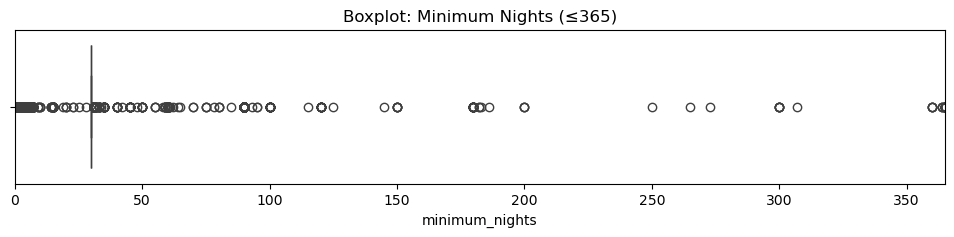

In [36]:
#Box plot for capped minimum nights
plt.figure(figsize=(12,2))
sns.boxplot(x=df['minimum_nights'])
plt.xlim(0, 365)
plt.title("Boxplot: Minimum Nights (≤365)")
plt.show()

Minimum nights distribution showed extreme values up to 1250 nights. Most listings clustered between 1-30 nights, with a spike at 30. To remove unrealistic long-term values, we capped 'minimum_nights' at **1-365**.

In [38]:
# Filtering Minimum Nights outliers
df = df[(df['minimum_nights'] >=1) & (df['minimum_nights'] <=365)]

print("Shape after filtering minimum_nights:", df.shape)
print(df['minimum_nights'].describe(percentiles=[.01, .05, 0.25, .5, .75, .95, .99]))

Shape after filtering minimum_nights: (20540, 24)
count    20540.000000
mean        27.908666
std         22.714016
min          1.000000
1%           1.000000
5%           1.000000
25%         30.000000
50%         30.000000
75%         30.000000
95%         30.000000
99%         90.000000
max        365.000000
Name: minimum_nights, dtype: float64


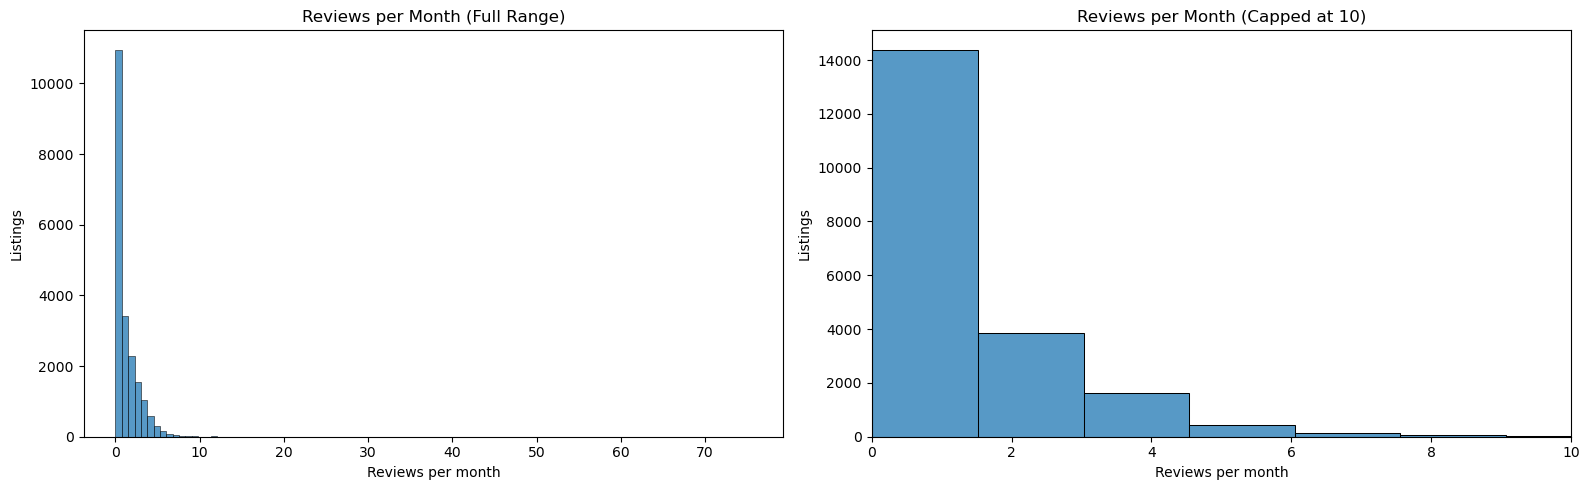

In [39]:
# Reviews per month distribution
fig, axes = plt.subplots(1,2, figsize = (16,5))

#Full range histogram
sns.histplot(df['reviews_per_month'], bins=100, kde = False, ax = axes[0])
axes[0].set_title("Reviews per Month (Full Range)")
axes[0].set_xlabel("Reviews per month")
axes[0].set_ylabel("Listings")

# Capped at 10 
sns.histplot(df['reviews_per_month'], bins=50, kde=False, ax=axes[1])
axes[1].set_xlim(0,10)
axes[1].set_title("Reviews per Month (Capped at 10)")
axes[1].set_xlabel("Reviews per month")
axes[1].set_ylabel("Listings")
plt.tight_layout()
plt.show()



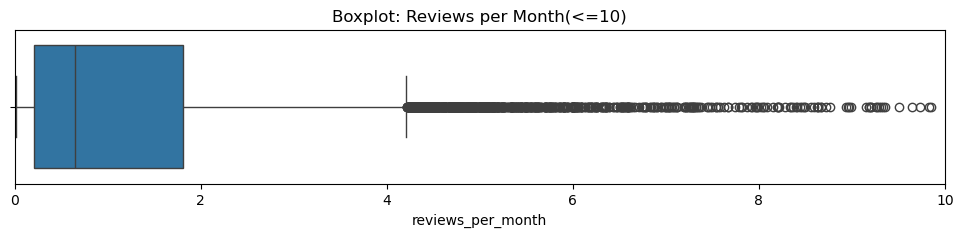

In [40]:
#Boxplot for capped view
plt.figure(figsize=(12,2))
sns.boxplot(x=df['reviews_per_month'])
plt.xlim(0,10)
plt.title("Boxplot: Reviews per Month(<=10)")
plt.show()

In [41]:
df = df[df['reviews_per_month'] <=10]
print("Shape after filtering reviews_per_month:", df.shape)
print(df['reviews_per_month'].describe(percentiles=[0.01, .05, 0.25, 0.5, 0.75, 0.95, 0.99]))

Shape after filtering reviews_per_month: (20486, 24)
count    20486.000000
mean         1.208379
std          1.373498
min          0.010000
1%           0.020000
5%           0.050000
25%          0.210000
50%          0.650000
75%          1.800000
95%          4.000000
99%          6.000000
max          9.850000
Name: reviews_per_month, dtype: float64


Reviews per month: Most listings have 0-2 reviews per month; $99\% \leq 6$. 

Extreme values up to 75 were unrealistic. We capped 'reviews_per_month' at **$\leq10$**, preserving 20,486 listings. 

#### Bivariate Analysis

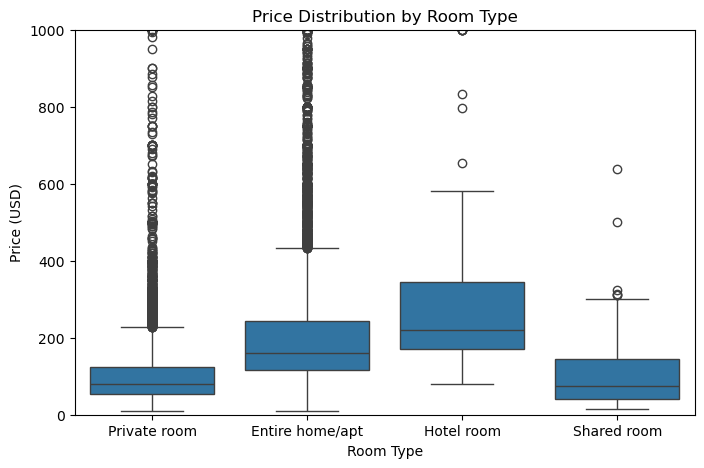

room_type
Shared room         75.0
Private room        80.0
Entire home/apt    160.0
Hotel room         221.0
Name: price, dtype: float64


In [44]:
# Price vs Room Type
plt.figure(figsize = (8,5))
sns.boxplot(x='room_type', y='price', data=df)
plt.ylim(0,1000)
plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price (USD)")
plt.show()

# Median Prices by room type
print(df.groupby('room_type')['price'].median().sort_values())

**Hotel rooms** are the most expensive on average. Entire home cost roughly double private/shared rooms. Shared and private rooms are priced similarly at the lower end. Distribution shows many outliers above $\$500$ for entire home and hotels. 

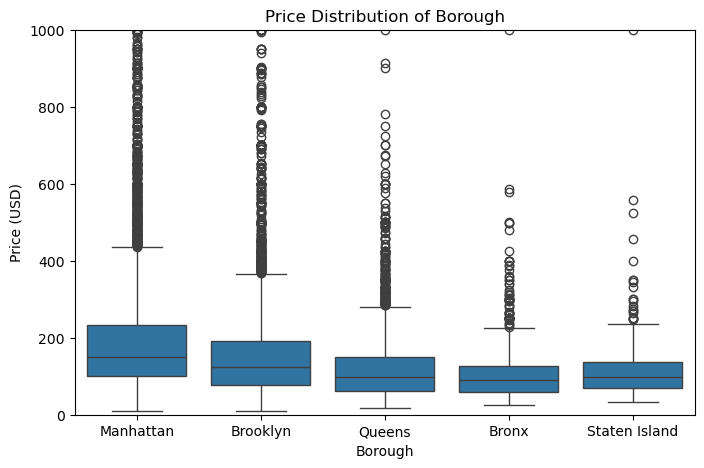

neighbourhood_group
Bronx             89.0
Queens            98.0
Staten Island     99.0
Brooklyn         124.0
Manhattan        150.0
Name: price, dtype: float64


In [46]:
# Price vs Neighbourhood Group (Boroughs)
plt.figure(figsize=(8,5))
sns.boxplot(x='neighbourhood_group', y='price', data =df, order=['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island'])
plt.ylim(0,1000)
plt.title("Price Distribution of Borough")
plt.xlabel("Borough")
plt.ylabel("Price (USD)")
plt.show()

# Median price by borough
print(df.groupby('neighbourhood_group')['price'].median().sort_values())

Manhattan is the most expensive borough, followed by Brooklyn. Outer boroughs (Bronx, Queens, Staten Island) are significantly cheaper. Consistent with expectations: central areas are pricier due to demand and location. 

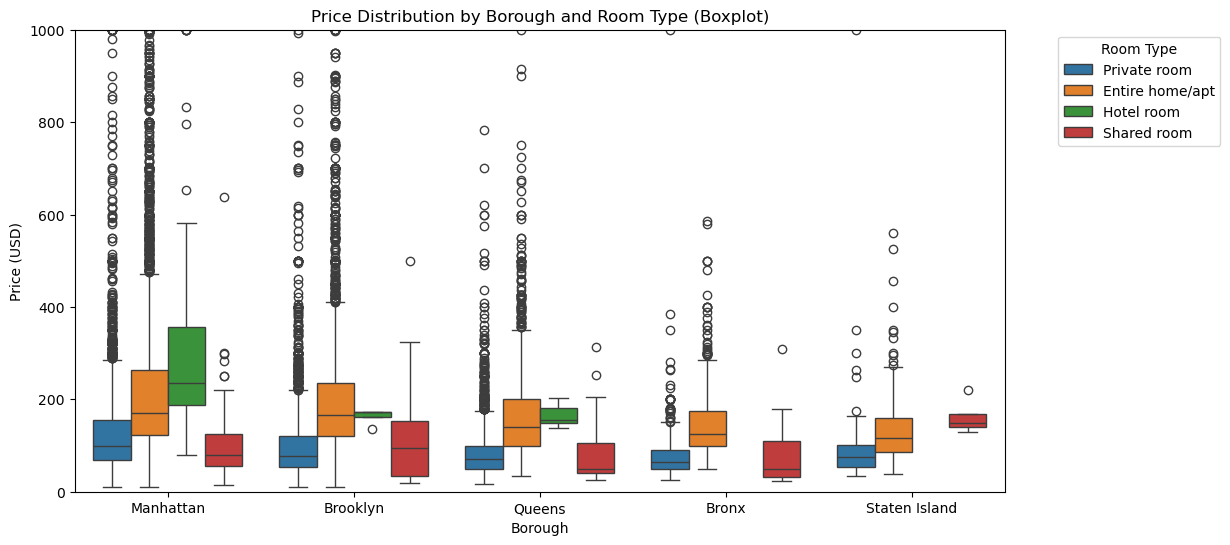

In [48]:
# Boxplot distribution of price by borough and room type
plt.figure(figsize=(12,6))
sns.boxplot(x='neighbourhood_group', y='price', hue='room_type', data =df, order=['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island'])
plt.ylim(0,1000)
plt.title("Price Distribution by Borough and Room Type (Boxplot)")
plt.xlabel("Borough")
plt.ylabel("Price (USD)")
plt.legend(title="Room Type", bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

In [49]:
#Calculating median prices
price_summary = df.groupby(['neighbourhood_group', 'room_type'])['price'].median().reset_index()

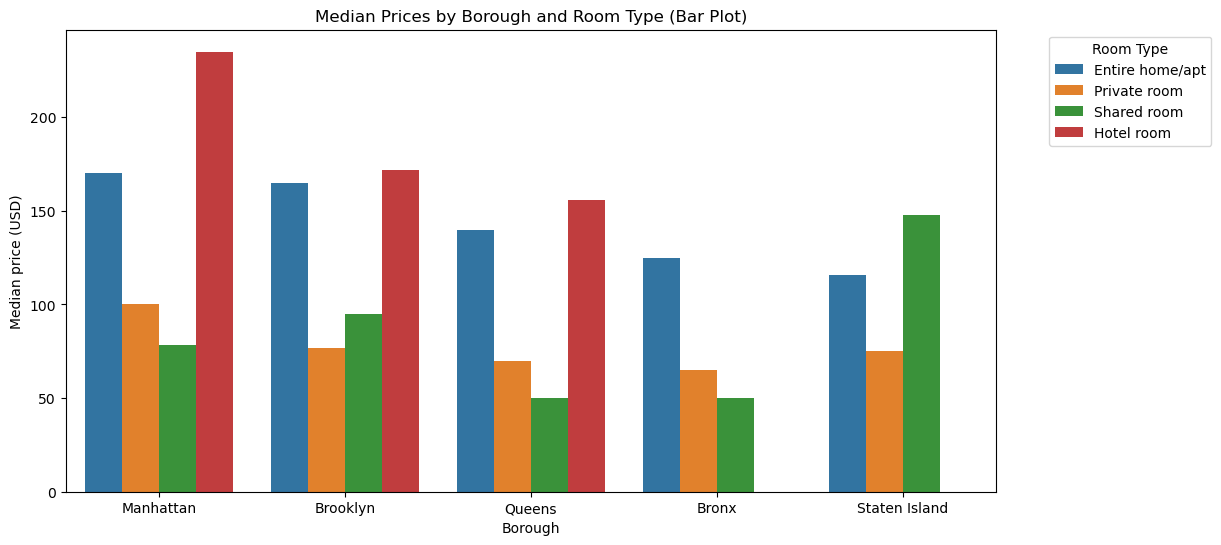

In [50]:
# Bar plot
plt.figure(figsize=(12,6))
sns.barplot(x='neighbourhood_group', y='price', hue='room_type', data = price_summary, order=['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island'])
plt.title("Median Prices by Borough and Room Type (Bar Plot)")
plt.xlabel("Borough")
plt.ylabel("Median price (USD)")
plt.legend(title="Room Type", bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

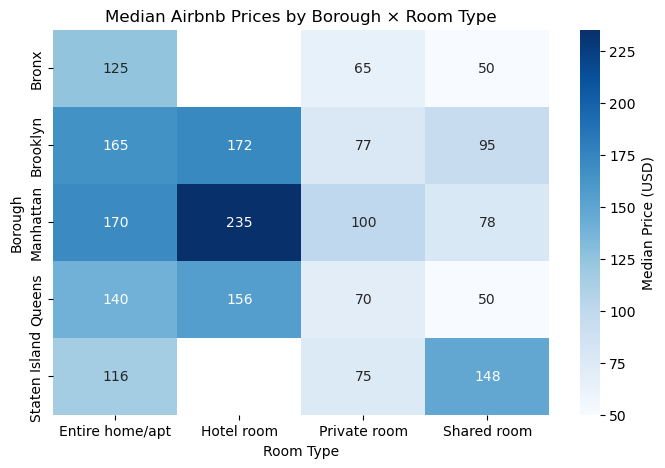

room_type,Entire home/apt,Hotel room,Private room,Shared room
neighbourhood_group,,,,
Bronx,125.0,NaN,65.0,50.0
Brooklyn,165.0,172.0,77.0,95.0
Manhattan,170.0,235.0,100.0,78.0
Queens,140.0,156.0,70.0,50.0
Staten Island,116.0,NaN,75.0,148.0


In [51]:
# Pivot table
pivot_table = df.pivot_table(values='price', index='neighbourhood_group', columns='room_type', aggfunc='median').round(0)
plt.figure(figsize=(8,5))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="Blues", cbar_kws={'label': 'Median Price (USD)'})
plt.title("Median Airbnb Prices by Borough × Room Type")
plt.xlabel("Room Type")
plt.ylabel("Borough")
plt.show()

# Display pivot table as well for reference
pivot_table

Price by Borough and Room Type
- **Borough Effect:**
  - Manhattan has the highest median prices ($\$150$ overall), followed by Brooklyn ($\$124$).  
  - Queens, Bronx, and Staten Island are significantly cheaper, with medians under $100.  

- **Room Type Effect:**  
  - Hotel rooms are the most expensive (median up to $\$235$ in Manhattan).  
  - Entire homes/apartments follow closely (median ~$\$170$ in Manhattan).  
  - Private rooms and shared rooms are the cheapest, with medians ~$\$75$–$\$100$.  

- **Combined Insights (Borough × Room Type):**  
  - The most expensive category is **Manhattan hotel rooms ($\$235$)**.  
  - The cheapest categories are **shared rooms in Bronx/Queens (~$\$50$)**.  
  - The price gap is most pronounced for entire homes and hotel rooms, while private/shared rooms show smaller differences across boroughs.

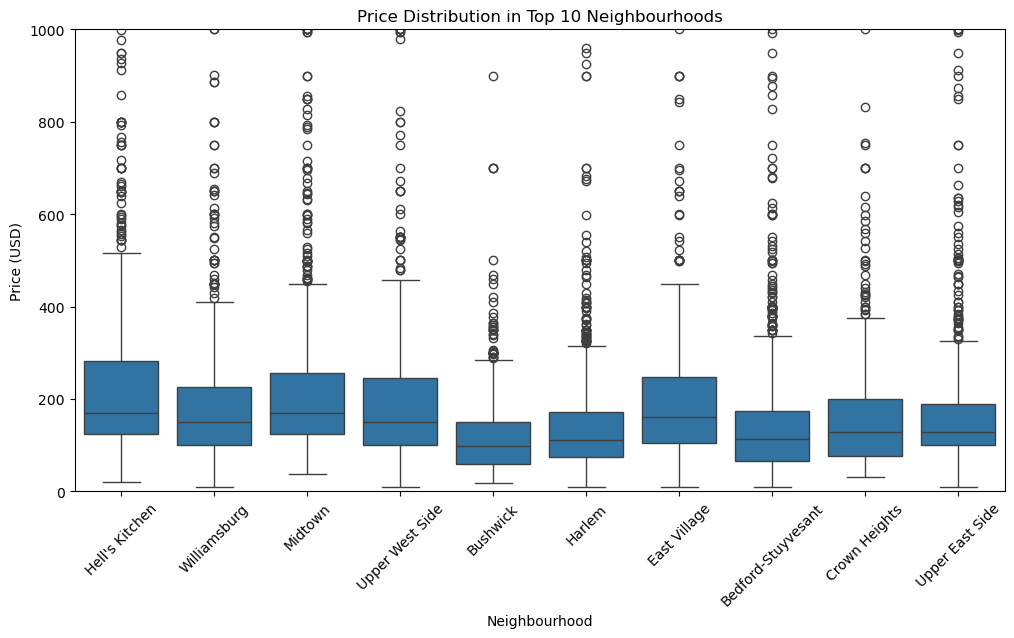

Median prices in top 10 neighbourhoods:
neighbourhood
Hell's Kitchen        170.0
Midtown               170.0
East Village          160.0
Upper West Side       150.0
Williamsburg          150.0
Crown Heights         129.0
Upper East Side       129.0
Bedford-Stuyvesant    113.0
Harlem                112.0
Bushwick               98.0
Name: price, dtype: float64


In [53]:
# Top 10 neighbourhoods by listing count
top_neighbourhoods = df['neighbourhood'].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.boxplot(x='neighbourhood', y='price', data=df[df['neighbourhood'].isin(top_neighbourhoods)])
plt.ylim(0, 1000)
plt.title("Price Distribution in Top 10 Neighbourhoods")
plt.xlabel("Neighbourhood")
plt.ylabel("Price (USD)")
plt.xticks(rotation=45)
plt.show()

# Median prices for reference
median_prices = df[df['neighbourhood'].isin(top_neighbourhoods)].groupby('neighbourhood')['price'].median().sort_values(ascending=False)
print("Median prices in top 10 neighbourhoods:")
print(median_prices)


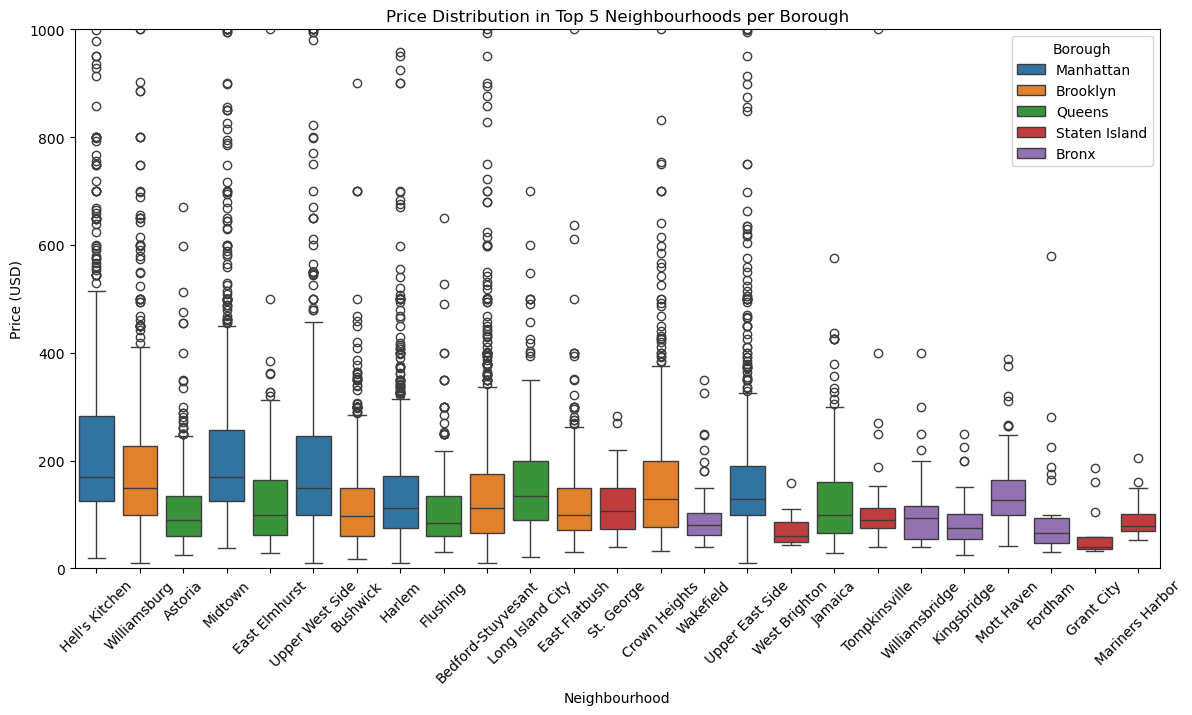

Median prices in top 5 neighbourhoods per borough:
neighbourhood_group  neighbourhood     
Manhattan            Midtown               170.0
                     Hell's Kitchen        170.0
                     Upper West Side       150.0
Brooklyn             Williamsburg          150.0
Queens               Long Island City      135.0
Brooklyn             Crown Heights         129.0
Manhattan            Upper East Side       129.0
Bronx                Mott Haven            126.5
Brooklyn             Bedford-Stuyvesant    113.0
Manhattan            Harlem                112.0
Staten Island        St. George            106.0
Brooklyn             East Flatbush         100.0
Queens               Jamaica               100.0
                     East Elmhurst          99.0
Brooklyn             Bushwick               98.0
Bronx                Williamsbridge         93.0
Queens               Astoria                90.0
Staten Island        Tompkinsville          89.0
Queens               Flushi

In [54]:
# Get top 5 neighbourhoods by count for each borough
top5_per_borough = (
    df.groupby(['neighbourhood_group','neighbourhood'])
    .size()
    .reset_index(name='count')
    .sort_values(['neighbourhood_group','count'], ascending=[True, False])
    .groupby('neighbourhood_group')
    .head(5)
)

# Filter dataset for only these top 5 per borough
df_top5 = df[df['neighbourhood'].isin(top5_per_borough['neighbourhood'])]

plt.figure(figsize=(14,7))
sns.boxplot(x='neighbourhood', y='price', data=df_top5, hue='neighbourhood_group')
plt.ylim(0, 1000)
plt.xticks(rotation=45)
plt.title("Price Distribution in Top 5 Neighbourhoods per Borough")
plt.xlabel("Neighbourhood")
plt.ylabel("Price (USD)")
plt.legend(title="Borough")
plt.show()

# Median prices for reference
median_prices = df_top5.groupby(['neighbourhood_group','neighbourhood'])['price'].median().sort_values(ascending=False)
print("Median prices in top 5 neighbourhoods per borough:")
print(median_prices)

##### Top 5 Neighbourhoods per Borough

- **Manhattan**: Midtown & Hell’s Kitchen ($\$170$) are the priciest, followed by Upper West Side ($\$150$). Even Harlem is above $\$100$.  
- **Brooklyn**: Williamsburg ($\$150$) is premium, while Bushwick & East Flatbush (~$\$100$) are more affordable.  
- **Queens**: Long Island City ($\$135$) is the hotspot; other areas (Jamaica, Astoria, Elmhurst) range $\$90–100$.  
- **Bronx**: Budget-friendly overall; Mott Haven ($\$126$) is higher, but Fordham is much cheaper ($\$65$).  
- **Staten Island**: St. George ($\$106$) is relatively higher; Grant City is the cheapest area citywide $(\$39)$.  



#### Multivariate Analysis

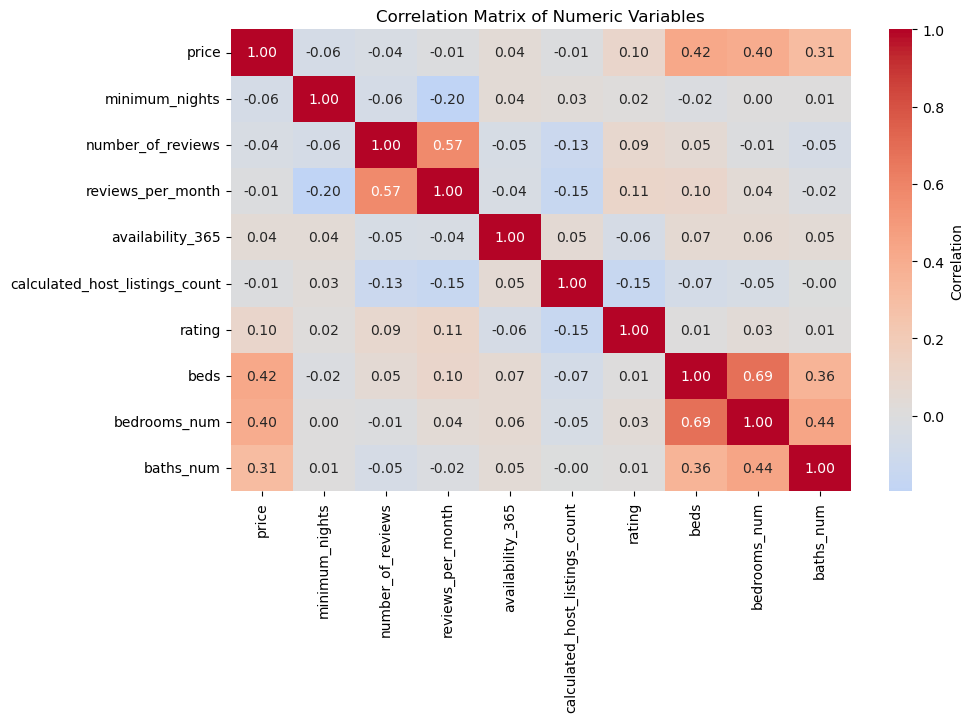

In [57]:
#Correlation Matrix
num_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365', 'calculated_host_listings_count', 'rating', 'beds', 'bedrooms_num', 'baths_num']

corr = df[num_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", cbar_kws={'label':'Correlation'})
plt.title("Correlation Matrix of Numeric Variables")
plt.show()

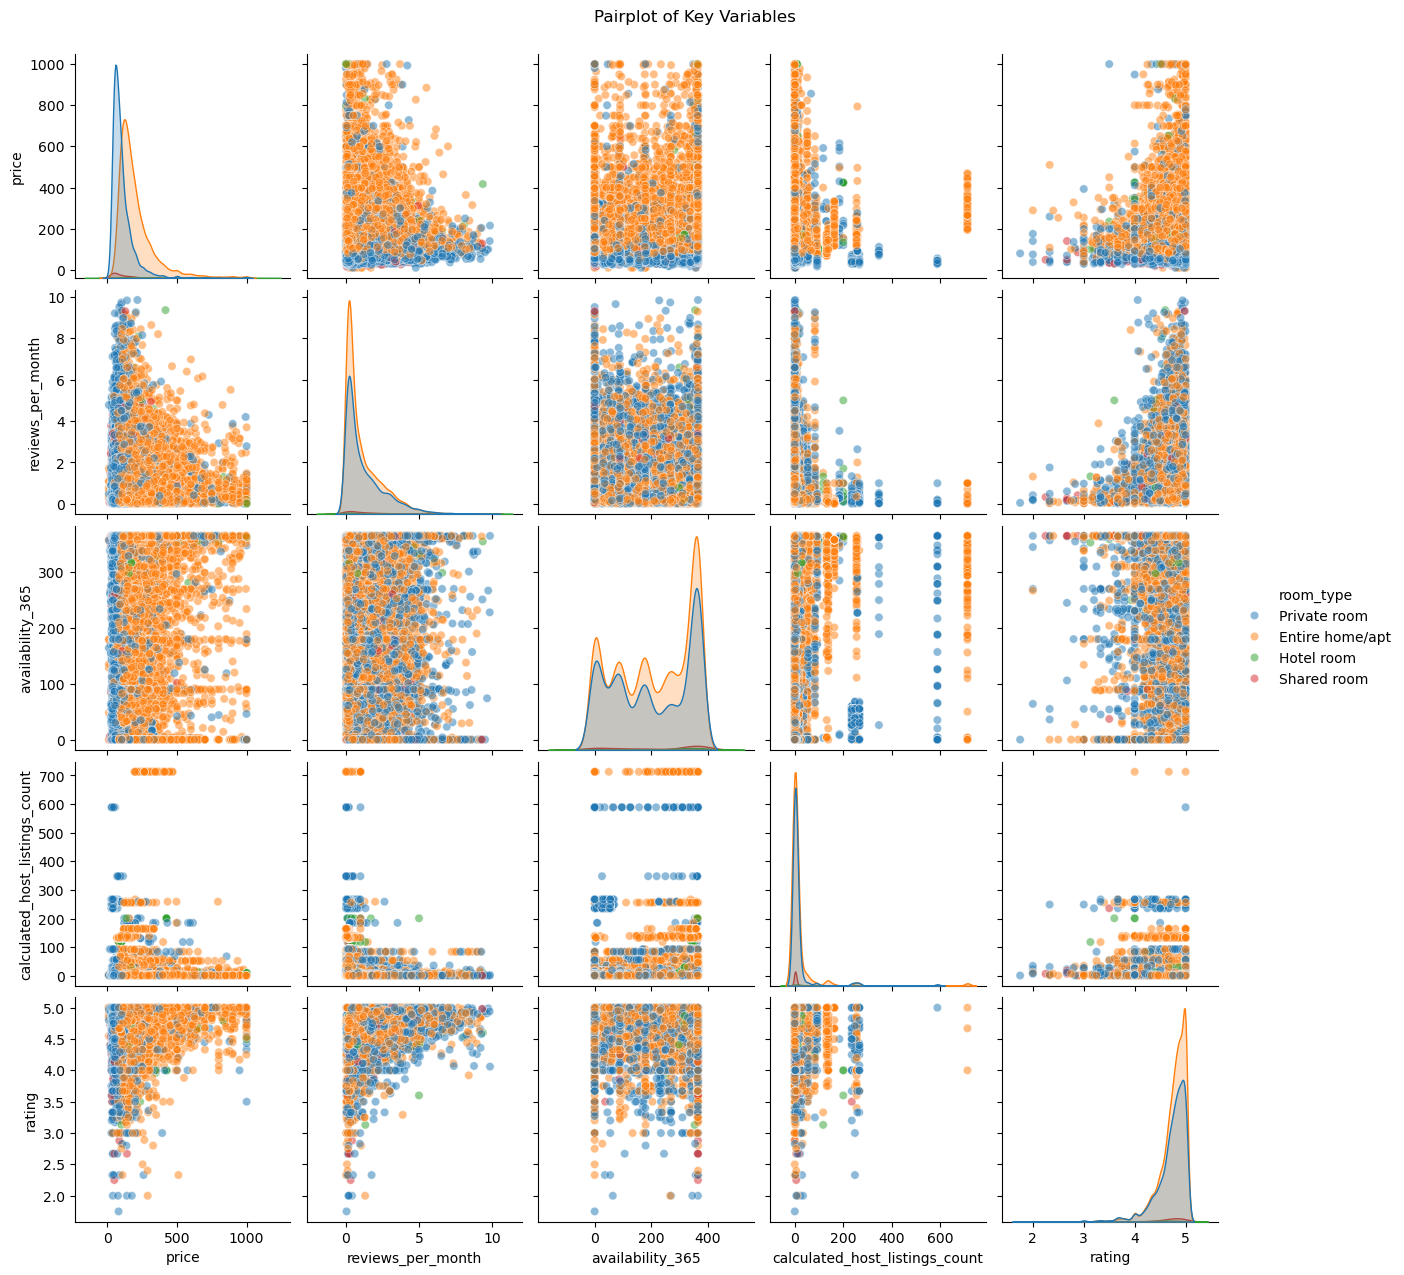

In [58]:
# Pairplot for key relationships
sns.pairplot(df[['price','reviews_per_month','availability_365',
                 'calculated_host_listings_count','rating', 'room_type']], 
             hue= 'room_type', diag_kind="kde", plot_kws={'alpha':0.5})
plt.suptitle("Pairplot of Key Variables", y=1.02)
plt.show()

### Inferential Statistics: Hypothesis Testing
#### Research Question 1: Do Prices Differ Across Boroughs and Room Types?

- Our `price` variable is heavily skewed, so **classical ANOVA assumptions** 
  (normality and homogeneity of variance) are violated.  
- Applying a **log transformation** makes the distribution more symmetric, 
  which allows us to test differences in means with ANOVA.  
- However, even after log transformation, group variances may still be unequal. 
  In that case, **Welch’s ANOVA** is more reliable because it does not assume equal variances.  
- Finally, if the log-normality assumption is still questionable, we also use the 
  **Kruskal-Wallis test** (non-parametric), which compares medians without relying on distributional assumptions.

**Hypotheses:**
- **$H_0$ (Null): There is no difference in nighly price across boroughs.**
- **$H_1$ (Alternate): At least one borough has significantly different nightly prices.** 

In [60]:
# Adding log(price)
df['log_price'] = np.log1p(df['price'])  # log(1+price) to avoid log(0)

# ANOVA on log(price)
model_borough = ols('log_price ~ C(neighbourhood_group)', data=df).fit()
anova_borough = sm.stats.anova_lm(model_borough, typ=2)
print("\nANOVA on log(price):")
print(anova_borough)


ANOVA on log(price):
                             sum_sq       df           F  PR(>F)
C(neighbourhood_group)   688.374930      4.0  416.499014     0.0
Residual                8462.569232  20481.0         NaN     NaN


In [61]:
# Welch’s ANOVA on log(price)
welch_borough = oneway.anova_oneway(
    df[['log_price','neighbourhood_group']].groupby('neighbourhood_group')['log_price'].apply(list),
    use_var='unequal',  # Welch correction
    welch_correction=True
)
print("Welch’s ANOVA for Boroughs:")
print(welch_borough)

Welch’s ANOVA for Boroughs:
statistic = 443.72047136003835
pvalue = 6.632930083356073e-265
df = (4.0, 1767.2521171851888)
df_num = 4.0
df_denom = 1767.2521171851888
nobs_t = 20486.0
n_groups = 5
means = [4.51714407 4.81975441 5.05546084 4.60227724 4.61439049]
nobs = [ 948. 7667. 7843. 3737.  291.]
vars_ = [0.31548466 0.43207544 0.4245415  0.38412277 0.30061299]
use_var = unequal
welch_correction = True
tuple = (443.72047136003835, 6.632930083356073e-265)


In [62]:
# Kruskal-Wallis on raw price
borough_groups = [df[df['neighbourhood_group']==b]['price'] for b in df['neighbourhood_group'].unique()]
kruskal_borough = stats.kruskal(*borough_groups)
print("\nKruskal-Wallis on raw price:")
print(kruskal_borough)


Kruskal-Wallis on raw price:
KruskalResult(statistic=1553.5959752408844, pvalue=0.0)


**Results:**
- ANOVA on log(price): F(4, 20481) = 416.5, p<0.001
- Welch's ANOVA on log(price): W(4, 1767) = 443.7, p<0.001
- Kruskal-Wallis on raw price: H = 1553.6, p < 0.001

**Conclusion:** All test confirms that **borough differ significantly in nightly prices.**

**Manhattan has the highest median prices, followed by Brooklyn, while Queens, Staten Island, and the Bronx are significantly cheaper.**

**Hypotheses:**
- **$H_0$ (Null): There is no difference in nightly prices across room types.**
- **$H_1$ (Alternate): At least one room type has significantly different nightly prices.**

In [65]:
# ANOVA on log(price)
model_room = ols('log_price ~ C(room_type)', data=df).fit()
anova_room = sm.stats.anova_lm(model_room, typ=2)
print("\nANOVA on log(price):")
print(anova_room)


ANOVA on log(price):
                   sum_sq       df            F  PR(>F)
C(room_type)  2470.661527      3.0  2525.047325     0.0
Residual      6680.282635  20482.0          NaN     NaN


In [66]:
# Welch’s ANOVA for Room Types
welch_room = oneway.anova_oneway(
    df[['log_price','room_type']].groupby('room_type')['log_price'].apply(list),
    use_var='unequal', 
    welch_correction=True
)
print("\nWelch’s ANOVA for Room Types:")
print(welch_room)


Welch’s ANOVA for Room Types:
statistic = 2460.994766420996
pvalue = 1.5511798118025478e-251
df = (3.0, 386.821640048907)
df_num = 3.0
df_denom = 386.821640048907
nobs_t = 20486.0
n_groups = 4
means = [5.15661316 5.50078653 4.46551754 4.36204005]
nobs = [11382.   106.  8712.   286.]
vars_ = [0.30052923 0.31285129 0.35393549 0.50518603]
use_var = unequal
welch_correction = True
tuple = (2460.994766420996, 1.5511798118025478e-251)


In [67]:
# Kruskal-Wallis on raw price
room_groups = [df[df['room_type']==rt]['price'] for rt in df['room_type'].unique()]
kruskal_room = stats.kruskal(*room_groups)
print("\nKruskal-Wallis on raw price:")
print(kruskal_room)


Kruskal-Wallis on raw price:
KruskalResult(statistic=5979.571034948925, pvalue=0.0)


**Results:**
- ANOVA on log(price): F(3, 20482) = 2525.0, p < 0.001
- Welch's ANOVA on log(price): W(3, 386.8) = 2461.0, p<0.001
- Kruskal-Wallis on raw price: H= 5979.6, p<0.001

**Conclusion:** All tests confirm that **room types differ significantly in nightly prices.**

Hotel rooms and entire homes/apartments are priced the highest, private room lower, and shared rooms lowest.

**Key Insights for RQ1**
- **Both borough and room type significantly affect ngihtly prices.**
- **Practical Difference:**
  - Manhattan and Brooklyn are premium boroughs, While Bronx and Queens are budget-friendly.
  - Hotel rooms and entire homes are priced much higher than private or shared rooms.
- **Market Segmentation:**
  - The most expensive segment is Manhattan hotel rooms.
  - The most affordable are shared rooms in the Bronx and Queens.
- The results show that **location and room type are critical determinants of pricing** in the NYC Airbnb market.

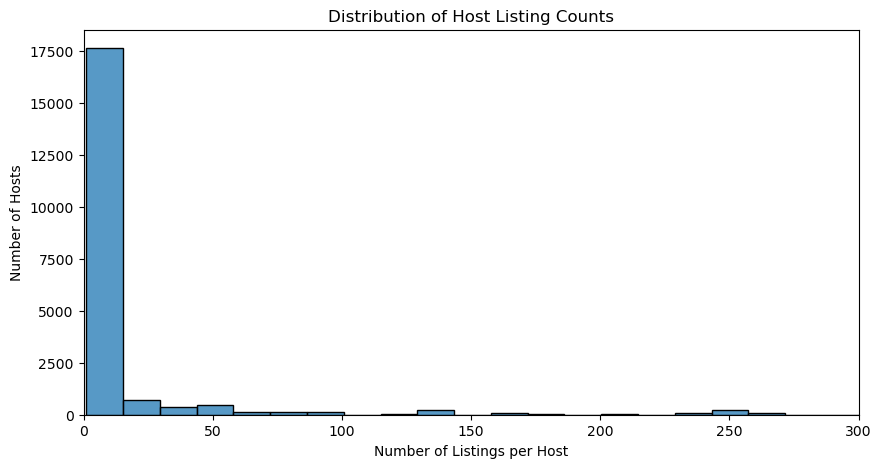

In [70]:
# Distribution of Host Listing Counts
plt.figure(figsize=(10,5))
sns.histplot(df['calculated_host_listings_count'], bins=50, kde=False)
plt.xlim(0,300)
plt.title("Distribution of Host Listing Counts")
plt.xlabel("Number of Listings per Host")
plt.ylabel("Number of Hosts")
plt.show()

#### Host listing distribution insights
- The distribution of host listings is highly skewed.
- Most hosts manage **only one listings**, indicating that Airbnb in NYC is dominated by individual or casual hosts.
- A small minority manage multiple listings, with a few hosting **over 200 properties**, suggesting the presence of professional or commercial operators.
- The variation supports further analysis of **host strategy** (single vs multi-listing) and how it may influence pricing and review activity. 

In [72]:
# Creating Host Type (Single vs Multi-listing)
df['host_type'] = df['calculated_host_listings_count'].apply(lambda x: 'Single' if x==1 else 'Multi')
# Checking distribution
print(df['host_type'].value_counts(normalize=True).round(2))

host_type
Multi     0.56
Single    0.44
Name: proportion, dtype: float64


#### Host type Distribution

- Hosts were categorized as:
   - **Single hosts:** manage exactly one listing.
   - **Multi hosts:** manage two or more listing.

**Results:**
- $56\%$ of listings are managed by **multi-listing hosts**, while $44\%$ belong to **single-listing hosts**.

**The majority of Airbnb supply in NYC is controlled by professional or commercial hosts, not individuals - a significant market insight for understanding pricing and competition.**

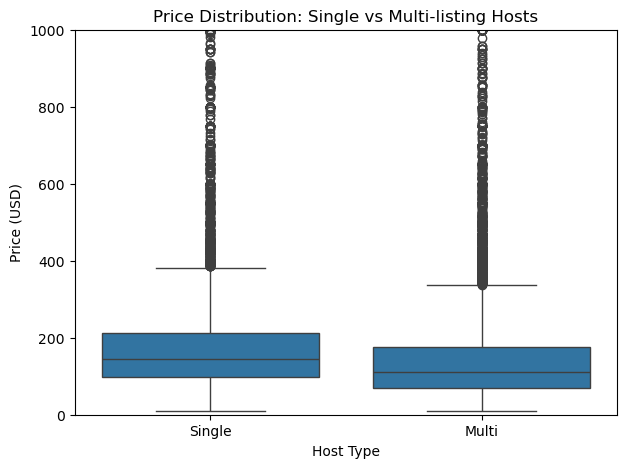

In [74]:
#Price Comparison by Host type
plt.figure(figsize=(7,5))
sns.boxplot(x='host_type', y='price', data =df)
plt.ylim(0,1000)
plt.title("Price Distribution: Single vs Multi-listing Hosts")
plt.xlabel("Host Type")
plt.ylabel("Price (USD)")
plt.show()

In [75]:
#Median Price by Host Type
median_price_host = df.groupby('host_type')['price'].median()
print("\n Median price by host type:")
print(median_price_host)



 Median price by host type:
host_type
Multi     110.0
Single    145.0
Name: price, dtype: float64


#### Price Comparison: Single vs Multi-Listing Hosts

- **Single hosts:** Median price = $\$145$
- **Multi hosts:** Median Price = $\$110$

**Insights:** Single-listing hosts tend to charge higher nightly prices than multi-listing (professional) hosts. This may indicate that single hosts often offer more personalized or premium spaces, while multi hosts compete on occupancy and volume with lower prices.

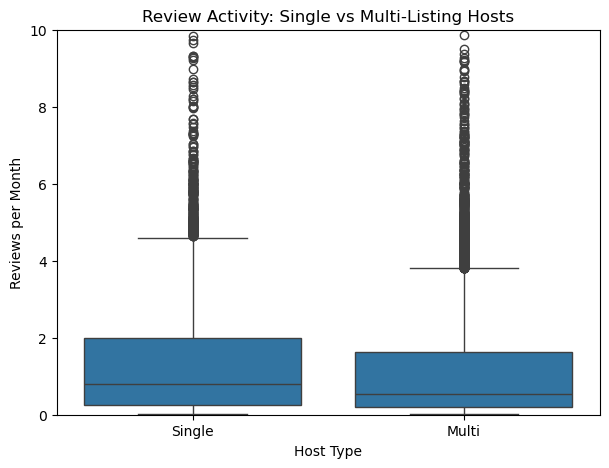

In [77]:
# Review Activity Comparison (Host Type vs Review per Month)
plt.figure(figsize=(7,5))
sns.boxplot(x='host_type', y='reviews_per_month', data =df)
plt.ylim(0,10)
plt.title("Review Activity: Single vs Multi-Listing Hosts")
plt.xlabel("Host Type")
plt.ylabel("Reviews per Month")
plt.show()

In [78]:
# Median reviews per month
median_reviews_host = df.groupby('host_type')['reviews_per_month'].median()
print("\n Median reviews per month by host type:")
print(median_reviews_host)


 Median reviews per month by host type:
host_type
Multi     0.54
Single    0.81
Name: reviews_per_month, dtype: float64


#### Review Activity: Single vs Multi-Listing Hosts

- **Median review per month:**
   - Single hosts: 0.81
   - Multi hosts: 0.54

**Insights:** Single-listing hosts receive more reviews per month compared to multi-listing hosts. This suggests they may attract higher engagement or offer more personalized guest experience, while multi hosts focus on managing many listings efficiently. 

Together with pricing patterns, this highlights two distinct hosting strategies:
- **Single hosts:** Higher prices and stronger guest engagement.
- **Multi hosts:** Lower prices and higher volume, but lower per-listing review activity.

Since both variables (price, reviews_per_month) are not normally distributed (right-skewed) and we're comparing two independent groups (Single vs Multi), the correct we will use is Mann-Whitney U Test (non-parametric alternative to independent t-test).

**(a) For Price**
- _$H_0$: Median price for single and multi hosts is the same._
- _$H_1$: Median price for single and multi hosts is different._

**(b) For Reviews per Month**
- _$H_0$: Median reviews per month for single and multi hosts are the same._
- _$H_1$: Median reviews per month for single and multi hosts are different._

In [80]:
# Price comparison (mannwhitneyu)
price_single = df[df['host_type']=='Single']['price']
price_multi = df[df['host_type']=='Multi']['price']

u_stat_price, p_value_price = mannwhitneyu(price_single, price_multi, alternative='two-sided')
print("Mann-Whitney U Test – Price:")
print(f"U= {u_stat_price:.2f}, p-value= {p_value_price:.5f}")


Mann-Whitney U Test – Price:
U= 62746750.00, p-value= 0.00000


In [81]:
# Reviews per month comparison (Mann-Whitney U)
rev_single = df[df['host_type']=='Single']['reviews_per_month']
rev_multi = df[df['host_type']=='Multi']['reviews_per_month']

u_stat_reviews, p_value_reviews = mannwhitneyu(rev_single, rev_multi, alternative='two-sided')
print("\nMann-whitney U Test - Reviews per Month:")
print(f"U= {u_stat_reviews:.2f}, p-value = {p_value_reviews:.5f}")


Mann-whitney U Test - Reviews per Month:
U= 56303885.50, p-value = 0.00000


#### Hypothesis Testing: Host Type Differences

**Tests Used:** Mann–Whitney U (non-parametric, two-tailed)

| Variable | U Statistic | p-value | Result | Direction |
|-----------|-------------:|---------:|---------|------------|
| Price | 62,746,750 | < 0.001 | Significant | Single hosts charge higher prices. |
| Reviews per Month | 56,308,553 | < 0.001 | Significant | Single hosts receive more reviews per month. |

**Conclusion:**
Both price and review activity differ significantly between single and multi hosts.
- **Single hosts** = higher prices and more reviews per listing.
- **Multi hosts** = lower prices but manage more listings overall.

This confirms statistically that **host type (strategy)** is an important factor influencing both pricing and guest engagement.


#### Research Question 2: What property and location characterstics are the strongest predictors of price?
We will model `price` (log-transformed, since prices are skewed) as a function of:

 **Categorical predictors:** `neighbourhood_group` (borough), `room_type`, `host_type`(Single vs Multi)
 
 **Numeric Predictors:** `beds`, `bedrooms_num`, `baths_num`, `rating`, `availability_365` and `reviews_per_month`

In [84]:
# target and features 
df['log_price'] = np.log1p(df['price'])  

features = [
    'neighbourhood_group', 'room_type', 'host_type',     
    'beds', 'bedrooms_num', 'baths_num',                 
    'rating', 'availability_365', 'reviews_per_month'    
]
X = df[features].copy()
y = df['log_price'].copy()

# checking where are the NaNs
print("NaNs per column:\n", X.isna().sum().sort_values(ascending=False).head(10))

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# preprocessors 
cat_cols = ['neighbourhood_group', 'room_type', 'host_type']
num_cols = ['beds', 'bedrooms_num', 'baths_num', 'rating', 'availability_365', 'reviews_per_month']

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, cat_cols),
        ('num', num_pipe, num_cols)
    ],
    remainder='drop'
)

#  model pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# fit & evaluate 
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nModel Performance on test set:\nR² = {r2:.3f}\nRMSE (log scale) = {rmse:.3f}")

# coefficient importance
# map coefficients back to feature names
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
coefs = model.named_steps['regressor'].coef_
imp = pd.Series(coefs, index=feature_names).sort_values(key=lambda s: s.abs(), ascending=False)

print("\nTop 15 absolute coefficients (log-price model):")
print(imp.head(15).round(3))

NaNs per column:
 rating                 3705
baths_num                13
neighbourhood_group       0
room_type                 0
host_type                 0
beds                      0
bedrooms_num              0
availability_365          0
reviews_per_month         0
dtype: int64

Model Performance on test set:
R² = 0.447
RMSE (log scale) = 0.488

Top 15 absolute coefficients (log-price model):
cat__room_type_Shared room               -0.666
cat__room_type_Private room              -0.461
cat__neighbourhood_group_Manhattan        0.460
cat__room_type_Hotel room                 0.418
num__rating                               0.202
cat__neighbourhood_group_Brooklyn         0.202
cat__host_type_Single                     0.183
num__bedrooms_num                         0.135
num__beds                                 0.104
num__baths_num                            0.090
cat__neighbourhood_group_Queens           0.060
cat__neighbourhood_group_Staten Island   -0.050
num__reviews_per_month  

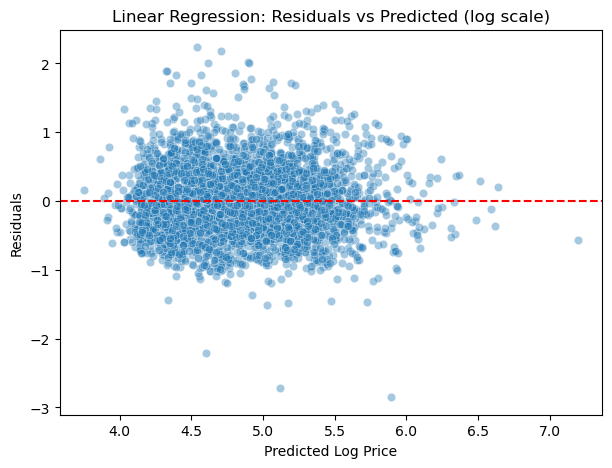

In [85]:
#Residual Analysis
#Predictions
y_pred_lr = model.predict(X_test)
residuals_lr = y_test - y_pred_lr

#Scatter plot: predicted vs residuals
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_pred_lr, y=residuals_lr, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title("Linear Regression: Residuals vs Predicted (log scale)")
plt.xlabel("Predicted Log Price")
plt.ylabel("Residuals")
plt.show()

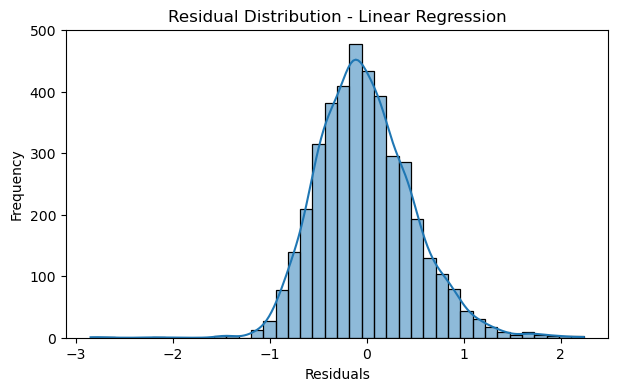

In [86]:
#Residual distribution
plt.figure(figsize=(7,4))
sns.histplot(residuals_lr, kde=True, bins=40)
plt.title("Residual Distribution - Linear Regression")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

**Linear Regression:**
- Residuals mostly centered around zero but show increasing spread at higher predicted prices.
- Indicates mild heteroscedasticity and unmodeled nonlinear effects.
- Residuals follow a near-normal distribution, confirming the log-transform helped stabilize variance. 

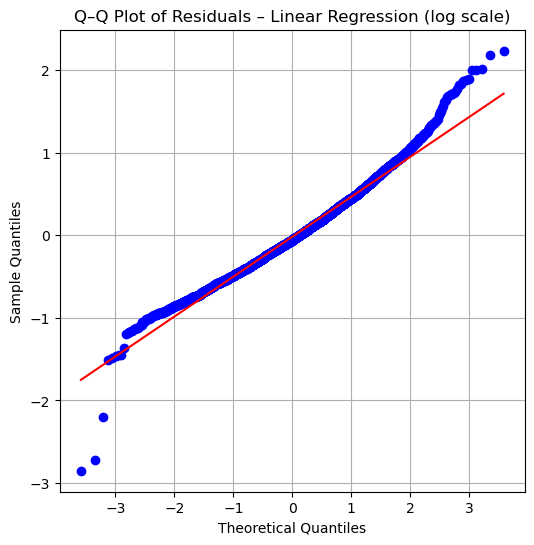

In [88]:
# Q–Q Plot for Linear Regression
plt.figure(figsize=(6,6))
stats.probplot(residuals_lr, dist="norm", plot=plt)
plt.title("Q–Q Plot of Residuals – Linear Regression (log scale)")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.show()

Residuals closely follow the 45° diagonal, indicating approximate normality after log transformation.  
  Slight deviations at the tails suggest minor outliers and heavier-than-normal tails,  
  which are acceptable in real-world pricing data.


In [90]:

tree_model = Pipeline(steps=[
    ('preprocessor', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)  
    ])),
    ('regressor', HistGradientBoostingRegressor(random_state=42))
])

tree_model.fit(X_train, y_train)
pred = tree_model.predict(X_test)
print("\nHistGBR Performance:")
print(f"R² = {r2_score(y_test, pred):.3f}, RMSE = {np.sqrt(mean_squared_error(y_test, pred)):.3f}")



HistGBR Performance:
R² = 0.546, RMSE = 0.442


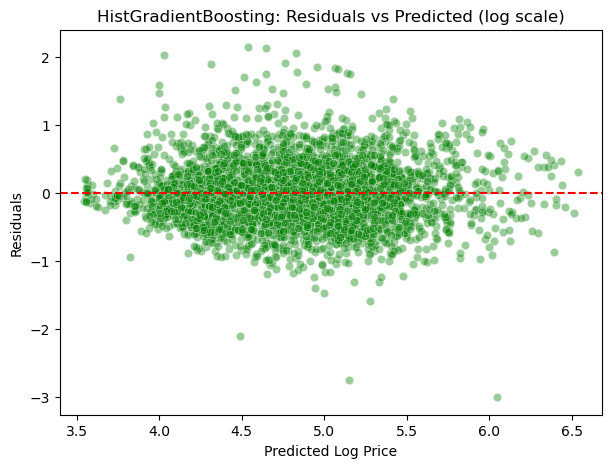

In [91]:
#HistGradient Boosting Residuals
#Predictions
y_pred_tree = tree_model.predict(X_test)
residuals_tree = y_test - y_pred_tree

#Scatter plot: Predicted vs Residuals
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_pred_tree, y=residuals_tree, alpha=0.4, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title("HistGradientBoosting: Residuals vs Predicted (log scale)")
plt.xlabel("Predicted Log Price")
plt.ylabel("Residuals")
plt.show()

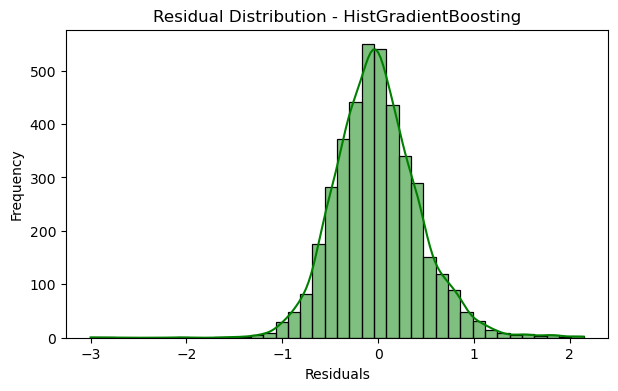

In [92]:
#Residual Distribution
plt.figure(figsize=(7,4))
sns.histplot(residuals_tree, kde=True, bins=40, color='green')
plt.title("Residual Distribution - HistGradientBoosting")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

**HistGradientBoosting:**
- Residuals are tightly centered around zero with no visible pattern.
- Distribution is symmetric with lower variance, indicating fewer large prediction errors.
- Confirms that the tree-based model fits better and handles nonlinearity and interactions effectively.

Residual analysis supports that **HistGradientBoosting provides a superior fits** over the linear model.

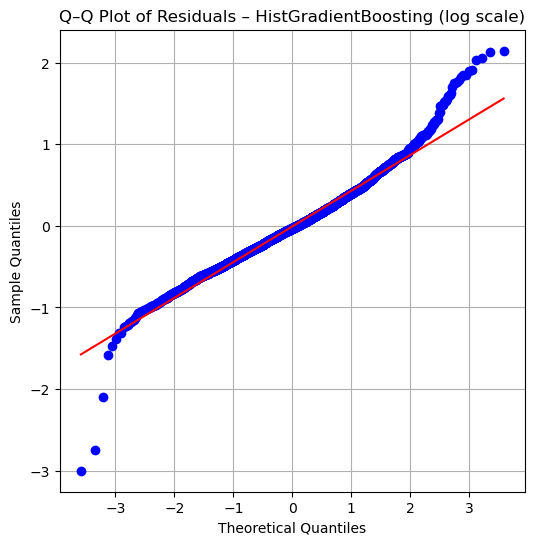

In [94]:
# Q–Q Plot for HistGradientBoosting
plt.figure(figsize=(6,6))
stats.probplot(residuals_tree, dist="norm", plot=plt)
plt.title("Q–Q Plot of Residuals – HistGradientBoosting (log scale)")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.show()

Residuals show mild tail deviation and less perfect alignment with the diagonal,  
  expected for a tree-based nonlinear model that does not assume normal residuals.  
  Nonetheless, the distribution remains symmetric and centered around zero,  
  confirming an unbiased fit.


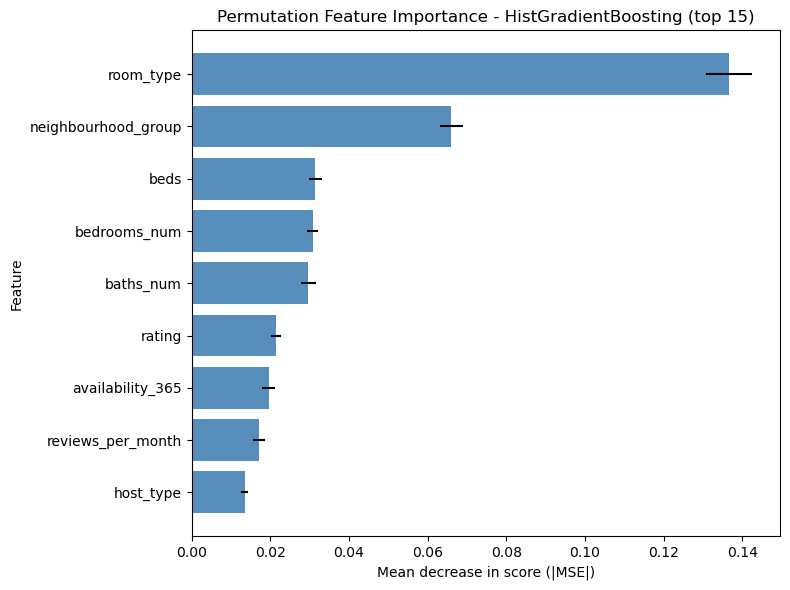

,Feature,Importance,Std
1,room_type,0.136649,0.005802
0,neighbourhood_group,0.066019,0.002873
3,beds,0.031449,0.001539
4,bedrooms_num,0.030746,0.001376
5,baths_num,0.029641,0.001876
6,rating,0.021468,0.001201
7,availability_365,0.019610,0.001678
8,reviews_per_month,0.017022,0.001504
2,host_type,0.013485,0.000906


In [96]:
#Feature importance visualization

#Names of the Original columns the pipeline receives
feature_names = np.array(getattr(X_test, "columns", list(X.columns)))

# Permutation importance on the pipeline (includes preprocessing)
perm = permutation_importance(
    tree_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_squared_error"
)

#Buidling a table
fi = pd.DataFrame({
    "Feature" : feature_names, 
    "Importance" : perm.importances_mean,
    "Std" : perm.importances_std
}).sort_values("Importance", ascending=False)

#Keeping top 10 for readability
topk = fi.head(10)

#Plot
plt.figure(figsize=(8,6))
plt.barh(topk["Feature"], topk["Importance"], xerr=topk["Std"], color="steelblue", alpha=0.9)
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance - HistGradientBoosting (top 15)")
plt.xlabel("Mean decrease in score (|MSE|)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#Displaying full table
fi

#### Feature Importance: HistGradientBoosting Model

**Top Predictors of Airbnb Prices**
| Feature | Importance | Interpretation |
|:--|:--:|:--|
| **Room Type** | **0.137** | Strongest driver of price; entire homes/hotel rooms much costlier than shared/private rooms. |
| **Borough (Neighbourhood Group)** | **0.066** | Location strongly impacts pricing; Manhattan and Brooklyn carry premium rates. |
| **Beds / Bedrooms / Baths** | ~0.03 | Property size increases price proportionally. |
| **Rating** | 0.021 | Higher-rated listings are slightly more expensive. |
| **Host Type** | 0.013 | Single hosts charge higher prices on average. |
| **Availability / Reviews** | ~0.02 | Minimal effect demand signals weakly correlated with pricing. |

**Conclusion:**
- Airbnb prices in NYC are **primarily determined by supply-side characteristics**: room type, location, and property size.  
- Host strategy and ratings add smaller but meaningful effects.  
- Demand metrics (reviews, availability) show minimal influence, confirming that pricing is largely driven by what hosts offer rather than guest activity.


#### Research Question 3: Do Multi-listing hosts set different prices compared to single-listing hosts?

This research question builds directly on host behavior analysis which we have already started in RQ2, but now we are zooming in specifically on pricing behavior differences i.e., host strategy. 

We already ran a Mann-Whitney test for median price differences that confirmed a significant difference. We can extend our regression model (from RQ2) to specifically test host pricing behavior while controlling for other features. 

Here we will be using our existing log-linear model and explicitly look at the host_type_Single coefficient this tells us how much more single hosts charge, all else being equal. 

In [99]:
#Simplified model focusing on host behavior
model_rq3 = ols('np.log1p(price) ~ C(host_type) + C(room_type) + C(neighbourhood_group) + beds + bedrooms_num + baths_num + rating', data=df).fit()

# View regression summary
print(model_rq3.summary())

                            OLS Regression Results                            
Dep. Variable:        np.log1p(price)   R-squared:                       0.435
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     1076.
Date:                Sun, 30 Nov 2025   Prob (F-statistic):               0.00
Time:                        18:30:46   Log-Likelihood:                -11721.
No. Observations:               16772   AIC:                         2.347e+04
Df Residuals:                   16759   BIC:                         2.357e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

#### Model Overview
- Model: OLS regression on log(price)
- R² = 0.435 → explains ~44% of price variance.
- N = 16,772 listings.
- Overall model: statistically significant (p < 0.001).

#### Key Results
| Variable | Coefficient | Significance | Interpretation |
|:--|--:|--:|:--|
| **Host Type (Single)** | **+0.159** | **p < 0.001** | Single hosts charge **≈17% higher prices** than multi hosts (holding other factors constant). |
| Room Type (Hotel room) | +0.459 | p < 0.001 | Hotel rooms are ≈58% more expensive than entire homes. |
| Room Type (Private room) | -0.432 | p < 0.001 | Private rooms are ≈35% cheaper. |
| Borough (Manhattan) | +0.428 | p < 0.001 | Manhattan listings ≈53% more expensive than baseline. |
| Beds / Bedrooms / Baths | +0.10–0.14 | p < 0.001 | Larger listings command higher prices. |
| Rating | +0.216 | p < 0.001 | Better-rated listings are priced higher. |

#### Conclusion
- **Host Type Effect:** Single hosts charge **significantly higher prices (~17%)** than multi hosts, even after controlling for property, location, and quality.  
- **Strategic Insight:**  
  - **Single hosts** likely offer more personalized or premium properties.  
  - **Multi hosts** operate at scale, possibly using competitive pricing to attract occupancy.  

This confirms a clear **pricing strategy difference** between single and multi-listing hosts in NYC.

### Research Question 4: How does host strategy influence guest engagement, as measured by reviews?

Our primary metric _reviews_per_month_ is already in the data; good because it's time-normalized. 

We will derive metric **availability-adjusted engagement** as
$$
\text{engagement\_adj} = \frac{\text{reviews\_per\_month}}{\max\left(\frac{\text{availability\_365}}{365}, 0.05\right)}
$$
(The denominator is a proxy for how available a place is; the 0.05 floor avoids exploding values for near-zero availability.)


In [102]:
#availability-adjusted engagement
df['availability_frac'] = np.clip(df['availability_365']/365.0, 0.05, None)
df['engagement_adj'] = df['reviews_per_month'] / df['availability_frac']

df[['reviews_per_month', 'availability_365', 'availability_frac', 'engagement_adj']].describe().T

,count,mean,std,min,25%,50%,75%,max
reviews_per_month,20486.0,1.208379,1.373498,0.01,0.210000,0.650000,1.800000,9.85
availability_365,20486.0,205.754027,134.932624,0.00,87.000000,214.000000,353.000000,365.00
availability_frac,20486.0,0.570363,0.359803,0.05,0.238356,0.586301,0.967123,1.00
engagement_adj,20486.0,5.953547,14.723950,0.01,0.420332,1.503909,4.387776,190.20


- _reviews_per_month_ : Mean $\approx$ 1.21, median $\approx$ 0.65 (most listings get fewer than 1 review per month (right-skewed)).
- _availability_365_ : Mean $\approx$ 205, median $\approx$ 214 (listings are typically available ~ 7 months per year).
- _availability_frac_: Median $\approx$ 0.59, so typical listing is available ~ 59$\%$ of the year.
- _engagement_adj_: Median $\approx$ 1.5, Mean $\approx$ 5.6, max 190 (some extreme values, likely a few listings with few available days but many reviews). 

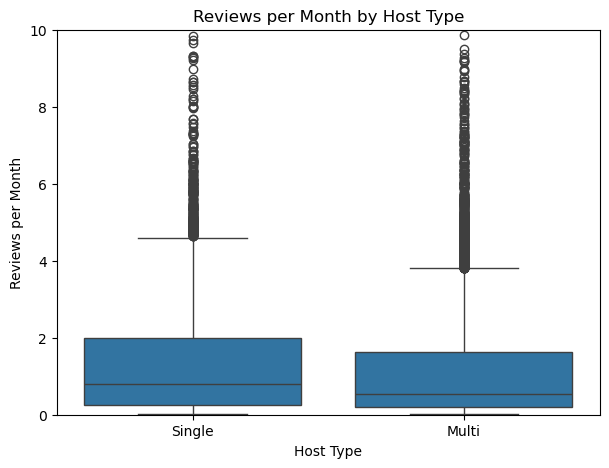

In [104]:
#Boxplots
plt.figure(figsize=(7,5))
sns.boxplot(x='host_type', y='reviews_per_month', data=df)
plt.ylim(0,10)
plt.title("Reviews per Month by Host Type")
plt.xlabel("Host Type")
plt.ylabel("Reviews per Month")
plt.show()

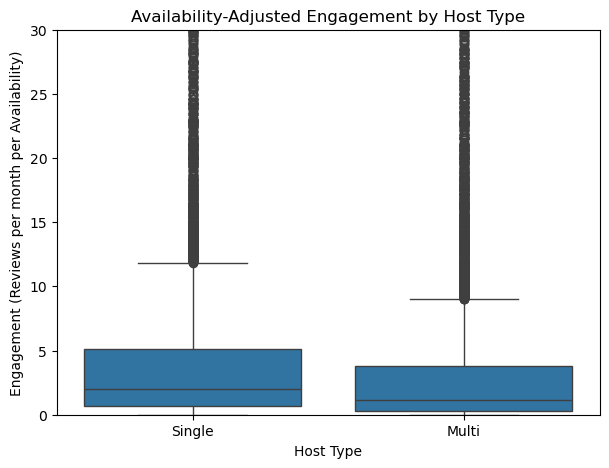

In [105]:
plt.figure(figsize=(7,5))
sns.boxplot(x='host_type', y='engagement_adj', data=df)
plt.ylim(0,30)
plt.title("Availability-Adjusted Engagement by Host Type")
plt.xlabel("Host Type")
plt.ylabel("Engagement (Reviews per month per Availability)")
plt.show()

Lets statistically verify the difference in medians. We are going to use Mann-Whitneyu U Test for this. 

Test (a): Reviews per Month by Host Type
- **$H_0$: No difference in median reviews_per_month between Single and Multi hosts.**
- **$H_1$: Medians differ between Single and Multi hosts.** 

In [107]:
rpm_single = df.loc[df['host_type']=='Single', 'reviews_per_month']
rpm_multi  = df.loc[df['host_type']=='Multi',  'reviews_per_month']
u_rpm, p_rpm = mannwhitneyu(rpm_single, rpm_multi, alternative='two-sided')
print(f"Mann–Whitney U (reviews_per_month): U={u_rpm:,.0f}, p-value={p_rpm:.5f}\n")

Mann–Whitney U (reviews_per_month): U=56,303,886, p-value=0.00000



Test (b): Availability-Adjusted Engagement

- **$H_0$: No difference in median engagement_adj between Single and Multi hosts.**
- **$H_1$: Medians differ between Single and Multi hosts.**

In [109]:
eng_single = df.loc[df['host_type']=='Single', 'engagement_adj']
eng_multi  = df.loc[df['host_type']=='Multi',  'engagement_adj']
u_eng, p_eng = mannwhitneyu(eng_single, eng_multi, alternative='two-sided')
print(f"Mann–Whitney U (engagement_adj): U={u_eng:,.0f}, p-value={p_eng:.5f}\n")

Mann–Whitney U (engagement_adj): U=60,898,669, p-value=0.00000



#### Test Used
Mann–Whitney U (non-parametric test for two independent groups)

#### Results
| Metric | U Statistic | p-value | Decision | Interpretation |
|:--|:--:|:--:|:--|:--|
| Reviews per Month | 56,303,886 | < 0.001 | Reject H₀ | Single hosts receive more reviews per month. |
| Engagement (Adj) | 60,898,669 | < 0.001 | Reject H₀ | Single hosts have higher engagement after adjusting for availability. |

#### Conclusion
There is a **statistically significant difference** in guest engagement between Single and Multi-listing hosts:
- **Single hosts** attract more reviews and stronger engagement, even when normalized for availability.
- This suggests that host strategy influences guest interaction and satisfaction possibly due to more personalized management or greater attention to guest experience.


So far, our exploratory and hypothesis testing steps have shown that: 
- Single hosts receive significantly more reviews and higher engagement than multi hosts.
- However, those tests compared host types without controlling for other important factors such as property size, location, room type, price and ratings.

To better understand the **true effect of host strategy** on guest engagement, we need to account for these confounding variables. 

We will build two regression models to analyze:
- **log(Reviews per Month)** -> measures raw engagement
- **log(Availability-Adjusted Engagement)** -> controls for listing availability

Each model will include:
- **Host Type** (`Single` vs `Multi`) — main independent variable.
- **Control Variables:**
  - Location: `neighbourhood_group` (borough)
  - Property type: `room_type`
  - Property size: `beds`, `bedrooms_num`, `baths_num`
  - Price and quality: `log_price`, `rating`
  - Availability: `availability_365`

We are doing this because:
Regression allows us to:
- Isolate the effect of **host type** on guest engagement.
- Control for differences in **location, property type, and pricing**.
- Quantify the **magnitude** of the difference.

In [111]:
#creating log base 10 tranformed engagement measures
df['log10_rpm'] = np.log10(df['reviews_per_month'] + 1)
df['log10_engagement_adj'] = np.log10(df['engagement_adj'] + 1)

#Log tranforming price to control skew
df['log_price'] = np.log1p(df['price'])

# Model 1: log10 (Raw Reviews per Month)
formula_rpm = """
log10_rpm ~ C(host_type) 
        + C(room_type)
        + C(neighbourhood_group)
        + log_price
        + beds + bedrooms_num + baths_num
        + rating + availability_365
"""
model_rpm = smf.ols(formula=formula_rpm, data=df).fit(cov_type="HC3")
print("Model 1: Predicting log10 (Reviews per Month)")
print(model_rpm.summary())


Model 1: Predicting log10 (Reviews per Month)
                            OLS Regression Results                            
Dep. Variable:              log10_rpm   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     80.96
Date:                Sun, 30 Nov 2025   Prob (F-statistic):          2.14e-225
Time:                        18:30:47   Log-Likelihood:                 1748.0
No. Observations:               16772   AIC:                            -3466.
Df Residuals:                   16757   BIC:                            -3350.
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

In [112]:
# Model 2: Availability-Adjusted Engagement
formula_adj = """
log10_engagement_adj ~ C(host_type)
                   + C(room_type)
                   + C(neighbourhood_group)
                   + log_price
                   + beds + bedrooms_num + baths_num
                   + rating + availability_365
"""
model_adj = smf.ols(formula=formula_adj, data=df).fit(cov_type="HC3")
print("\nModel 2: Predicting log10(Availability-Adjusted Engagement)")
print(model_adj.summary())



Model 2: Predicting log10(Availability-Adjusted Engagement)
                             OLS Regression Results                             
Dep. Variable:     log10_engagement_adj   R-squared:                       0.434
Model:                              OLS   Adj. R-squared:                  0.433
Method:                   Least Squares   F-statistic:                     710.4
Date:                  Sun, 30 Nov 2025   Prob (F-statistic):               0.00
Time:                          18:30:47   Log-Likelihood:                -5709.0
No. Observations:                 16772   AIC:                         1.145e+04
Df Residuals:                     16757   BIC:                         1.156e+04
Df Model:                            14                                         
Covariance Type:                    HC3                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------

In [113]:
# Calculating percent effect of host_type coefficient (Single vs Multi)
for model, name in zip([model_rpm, model_adj], ["Reviews per Month", "Adjusted Engagement"]):
    beta = model.params.get('C(host_type)[T.Single]', np.nan)
    if not np.isnan(beta):
        pct = (np.exp(beta) - 1) * 100
        print(f"\nEffect of Single Host on {name}: {pct:.1f}%")


Effect of Single Host on Reviews per Month: 1.4%

Effect of Single Host on Adjusted Engagement: -0.5%


#### Key Findings

| Model | Dependent Variable | Host Type Effect | p-value | Interpretation |
|:--|:--|:--:|:--:|:--|
| **Model 1** | log₁₀(Reviews per Month) | +0.0136 → **+1.4%** | < 0.001 | Single hosts receive ~1.4% more reviews per month than multi hosts. |
| **Model 2** | log₁₀(Availability-Adjusted Engagement) | -0.0055 → **-0.5%** | 0.327 | Once availability is controlled, engagement difference disappears. |
---

#### Interpretation
- **Initial Difference:** Single hosts show slightly higher guest engagement (more reviews/month).  
- **After Adjustment:** Once availability, property features, and location are controlled for, the effect disappears suggesting that the engagement difference is explained by **operational factors** (availability, booking frequency) rather than host behavior itself.

---

#### Conclusion
- Host strategy influences engagement at the **surface level** single hosts appear to get more reviews overall.  
- However, after accounting for listing availability and other variables, **both host types perform similarly** in terms of engagement efficiency.  
- This indicates that **multi hosts manage more listings with lower per-listing engagement**, while **single hosts achieve slightly higher engagement through fewer, more frequently booked listings**.

**In essence:**  
> Single hosts engage guests more often per month, but not more effectively once availability and listing characteristics are controlled for.

### Research Question 5: Can listings be classified into high-demand vs low-demand segments based on review activity?

To identify whether Airbnb listings can be classified into **high-demand** and **low-demand** groups based on their review activity and other listings features. 

We will use `reviews_per_month` as the indicator of demand. Classifing listings into: 
- High demand ($\geq$ median reviews/month)
- Low demand (< median reviews/month)

We will build a **Logistic Regression model** to predict demand segment based on: Price, availability, rating, property size, room type, borough, and host type. And evaluate model accuracy and identify which features most influence listing demand.

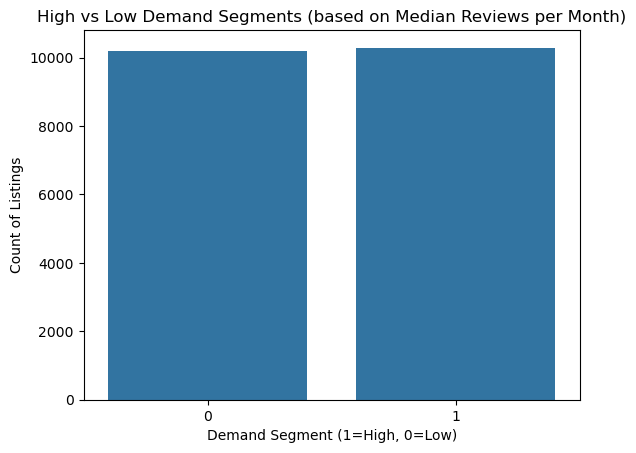

demand_segment
1    0.502245
0    0.497755
Name: proportion, dtype: float64


In [116]:
# Defining binary demand segment
median_reviews = df['reviews_per_month'].median()
df['demand_segment'] = np.where(df['reviews_per_month'] >= median_reviews, 1, 0)

# Checking distribution
sns.countplot(x='demand_segment', data=df)
plt.title("High vs Low Demand Segments (based on Median Reviews per Month)")
plt.xlabel("Demand Segment (1=High, 0=Low)")
plt.ylabel("Count of Listings")
plt.show()

print(df['demand_segment'].value_counts(normalize=True))

The chart and counts confirm that the split into **High Demand (1)** and **Low Demand (0)** segments is balanced (~50-50), which is ideal for modeling because it prevents class imbalance bias. 

Best params: {'clf__C': 1.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Accuracy: 0.593 | ROC-AUC: 0.634

Classification report:
               precision    recall  f1-score   support

           0      0.591     0.590     0.590      2549
           1      0.594     0.596     0.595      2573

    accuracy                          0.593      5122
   macro avg      0.593     0.593     0.593      5122
weighted avg      0.593     0.593     0.593      5122



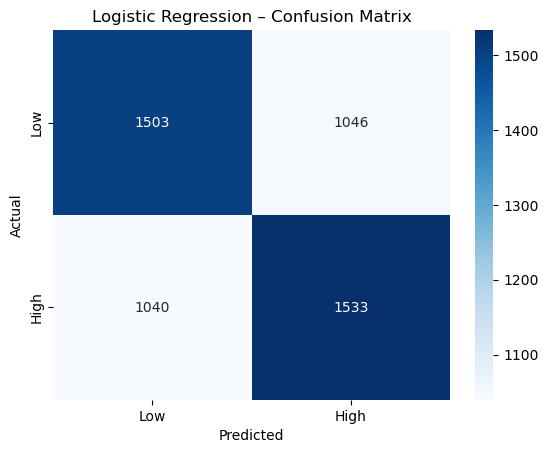

In [118]:
cat_cols = ['host_type', 'room_type', 'neighbourhood_group']
num_cols = ['log_price', 'availability_365', 'rating', 'beds', 'bedrooms_num', 'baths_num']
features = cat_cols + num_cols
target = 'demand_segment'

# Build X/y
XY = df[features + [target]].dropna(subset=[target]).copy()
X = XY[features]
y = XY[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Preprocessor: impute + scale numeric, impute + onehot categorical
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipe, cat_cols),
    ('num', num_pipe, num_cols)
])

# Logistic regression pipeline
logit = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=5000))
])

# Small grid to address convergence/regularization
param_grid = {
    'clf__solver': ['lbfgs', 'liblinear', 'saga'],   # try several solvers
    'clf__penalty': ['l2'],                          # liblinear/saga support more, but start with l2
    'clf__C': [0.25, 0.5, 1.0, 2.0],
}

gs = GridSearchCV(
    logit, param_grid=param_grid,
    scoring='roc_auc', cv=5, n_jobs=-1, verbose=0
)

gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
best = gs.best_estimator_

# Evaluate
y_pred = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:, 1] if hasattr(best, "predict_proba") else best.decision_function(X_test)

acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)
print(f"Accuracy: {acc:.3f} | ROC-AUC: {auc:.3f}\n")
print("Classification report:\n", classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Logistic Regression – Confusion Matrix')
plt.show()

In [119]:
# non-linear model for NaNs & better collinearity
tree_clf = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ])),
    ('clf', HistGradientBoostingClassifier(random_state=42))
])

tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
y_proba_tree = tree_clf.predict_proba(X_test)[:,1]
print(f"HistGBC Accuracy: {accuracy_score(y_test, y_pred_tree):.3f} | ROC-AUC: {roc_auc_score(y_test, y_proba_tree):.3f}")


HistGBC Accuracy: 0.755 | ROC-AUC: 0.825


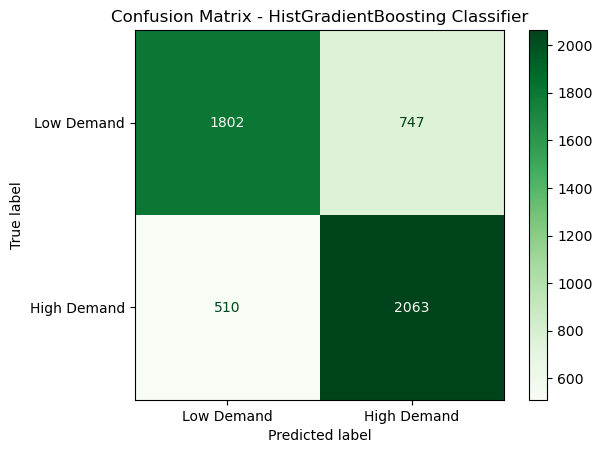

In [201]:
cm_tree = confusion_matrix(y_test, y_pred_tree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['Low Demand', 'High Demand'])
disp.plot(cmap='Greens')
plt.title("Confusion Matrix - HistGradientBoosting Classifier")
plt.show()

Random Forest Accuracy: 0.714
Random Forest ROC-AUC: 0.786

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.69      0.70      2549
           1       0.70      0.74      0.72      2573

    accuracy                           0.71      5122
   macro avg       0.71      0.71      0.71      5122
weighted avg       0.71      0.71      0.71      5122



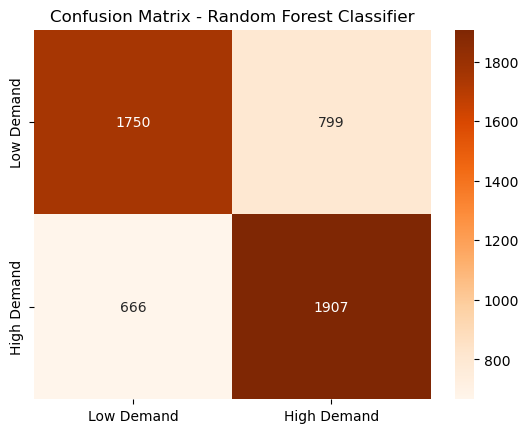

In [209]:
#lets try random forest model as well
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Random Forest ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Low Demand', 'High Demand'],
            yticklabels=['Low Demand', 'High Demand'])
plt.title("Confusion Matrix - Random Forest Classifier")
plt.show()


Okay, so, we have classified listings into **high-demand** and **low-demand** categories using review activity  
(`reviews_per_month`) and listing characteristics (price, location, room type, host type, rating, and availability).

---

**Model Performance Summary**

| Model | Accuracy | ROC-AUC | Interpretation |
|------|----------|---------|----------------|
| **Logistic Regression** | 0.593 | 0.634 | Linear model captures limited relationships; demand is complex and nonlinear. |
| **Random Forest Classifier** | 0.714 | 0.786 | Captures nonlinear interactions; strong improvement over baseline. |
| **HistGradientBoosting** | **0.755** | **0.825** | Best overall performance; models complex interactions between pricing, rating & availability. |

---

**Key Insights**

- **Demand segmentation is highly nonlinear** — price, rating, availability, and room type influence demand jointly, not independently.
- **High-demand listings** tend to be:
  - Lower-priced and higher-rated,
  - Often private or shared rooms,
  - Located in moderately priced boroughs (e.g., Brooklyn, Queens),
  - Sometimes operated by single hosts with fewer listings.
- **Low-demand listings** are more often:
  - High-priced entire homes or hotel-style units,
  - Located in premium boroughs (e.g., Manhattan),
  - Managed by multi-listing hosts with high availability but lower review volume.
- **Tree-based models** (Random Forest & HistGradientBoosting) effectively capture these nonlinear behavioral patterns and  
  significantly outperform simpler linear approaches.

---

**Conclusion:**  
Yes — Airbnb listings can be accurately classified into **high-demand** and **low-demand** groups, but only by using  
**nonlinear ensemble models**. These models uncover meaningful market segments that align with real host strategies, pricing  
behavior, and guest engagement patterns.


### Research Question 6: What Clusters of Listings Exist Based on Price, Host Behavior, Reviews, and Ratings?

To Identify natural market segments among NYC Airbnb Listings by clustering listings based **price**, **reviews**, **ratings**, **availability**, and **host type**. 

We will standardize continuous features and encode host type. Use **K-Means clustering** to group listings. Determine optimal cluster count using the **Elbow Method**. Visualize clusters using **PCA projection**. And finally interpret each cluster as a distinct market segment. 

This analysis reveals natural market structures, showing how price, host strategy, and guest engagement interact to shape different types of Airbnb listings. 


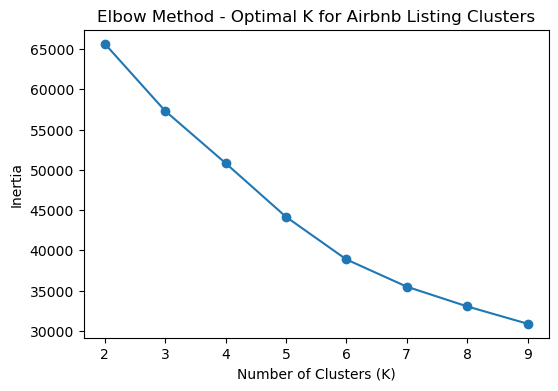

In [122]:
# Selecting Clustering features
cluster_features = ['log_price', 'rating', 'reviews_per_month', 'availability_365']

# Encoding host_type (binary)
df['host_type_encoded'] = df['host_type'].map({'Single': 1, 'Multi': 0})
cluster_features.append('host_type_encoded')

# Droping missing values
df_cluster = df[cluster_features].dropna()

# Standardize features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# Determining optimal number of clusters (Elbow Method) 
inertia = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method - Optimal K for Airbnb Listing Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()


In [123]:
#Fitting KMeans with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

#Adding cluster labels to the Data Frame
df_cluster['cluster'] = clusters

#Cluster summary
cluster_summary = df_cluster.groupby('cluster').mean().round(2)
cluster_summary['count'] = df_cluster['cluster'].value_counts()
cluster_summary = cluster_summary.sort_index()
cluster_summary

,log_price,rating,reviews_per_month,availability_365,host_type_encoded,count
cluster,,,,,,
0,5.00,4.82,1.51,182.92,1.00,7345
1,4.82,4.78,1.12,320.75,0.00,4501
2,4.62,3.99,0.62,237.85,0.23,1297
3,4.69,4.76,1.87,86.32,0.00,3638


**Key Findings**

| Cluster | Description | Characteristics |
|:--|:--|:--|
| **0 — Mid-Priced Single Host Leaders** | Personalized, high-quality listings run by single hosts. | Medium price, high rating, steady reviews, moderate availability. |
| **1 — High-Availability Multi Hosts** | Volume-focused commercial operators. | Low price, high availability, moderate engagement. |
| **2 — Low-Rated & Low-Demand Listings** | Underperforming or low-quality segment. | Lowest ratings, few reviews, low guest satisfaction. |
| **3 — Budget High-Demand Properties** | Fully booked, high-turnover listings. | Cheapest, lowest availability, highest reviews per month. |

Four distinct Airbnb market clusters exist in NYC:

1. **Mid-range, quality-driven single hosts** form the platform’s most stable and reputable segment.  
2. **Multi-host budget operators** maintain steady bookings via high availability.  
3. **Low-quality listings** risk underperformance due to poor guest experiences.  
4. **Budget high-demand units** thrive on frequent bookings despite low prices.  

These clusters highlight the **diversity of host strategies** and reveal how **price, quality, and engagement jointly define Airbnb market structure** in New York City.
